# Congestion Revenue Allocation on the WSCC 9-Bus Network

This notebook builds a unified WSCC 9-bus nodal clearing, then partitions
the network into two balancing authorities (BAs) joined by two tie lines, to
study congestion revenue allocation when one BA's internal
constraint separates prices in the other.

The Western Systems Coordinating Council (WSCC) 9-bus test case is a simple approximation of the WSCC grid, reduced to an equivalent system with nine buses, three loads, and three generators.

| Section | What you see |
|---|---|
| **0-2. Shared network, shift factors, unified clearing** | DC power flow, nodal LMPs $\lambda_n$, and the per-line congestion-rent decomposition $\sum_m |\mu_m|\bar F_m$ |
| **3. Two balancing authorities** | The BA partition, the configurable line assignment, and the congestion-revenue ledger |
| **The scenario: internal constraint, external separation** | One BA's *internal* limit separates prices in the *other* BA across the border |
| **Allocation** | **Method 1** (home BA keeps it) vs **Method 2** (rebate cross-border separation), side by side |
| **Unified vs independent** | Whether the cross-border rent survives independent (uncoordinated) operation |
| **4. Optimized transfers** | An EDAM-style scheduling limit on the border interchange; transfer rent as a second revenue stream — collected at the border, allocated by configurable rules — with an autarky comparison and Pareto check |

All computation uses [`seams_engine.py`](seams_engine.py); the allocation
methodology is defined inline below so it can be tuned. 

## 0. Setup

In [1]:
#@title ▶ Run me first — Colab setup (installs packages, fetches the helper modules)
# On Google Colab this installs the few non-default packages and downloads the
# three helper modules next to the notebook. Running locally it does nothing
# (the modules are already on disk), so the same notebook works in both places.
import sys, subprocess

def _sh(cmd):
    print("$", cmd)
    subprocess.run(cmd, shell=True, check=True)

if "google.colab" in sys.modules:
    _sh("pip install -q pypsa pandapower pycirclize")
    _base = "https://raw.githubusercontent.com/pdockery/wscc9-illustrative-model/main"
    for _f in ("ieee9_network.py", "seams_engine.py", "nodal_plot.py"):
        _sh(f"wget -q {_base}/{_f} -O {_f}")
    print("Colab setup complete.")
else:
    print("Local run: using the modules already in this folder.")


Local run: using the modules already in this folder.


In [2]:
import sys, os, importlib
import warnings; warnings.filterwarnings('ignore')
import logging; logging.getLogger('pypsa').setLevel(logging.ERROR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('.'))

from ieee9_network import build_ieee9_network
import seams_engine, nodal_plot
importlib.reload(seams_engine); importlib.reload(nodal_plot)
from seams_engine import (
    compute_ptdf, MarketEngine, solve_engine_dispatch,
    physical_flows, seam_dual_gap, to_supply_demand, susceptance_widths,
    shed_segments, served_by_bus, served_demand,
)
from nodal_plot import (
    plot_network_topology, plot_nodal_circlize,
    assign_bus_colors, BUS_PALETTE, TRANSIT_COLOR,
)
pd.set_option('display.width', 160)

# Clean tables on PDF export: give DataFrames/Series a booktabs LaTeX rendering.
# Jupyter and Colab still show the normal HTML tables; `nbconvert --to pdf` picks
# up this text/latex representation, so tables come out as real ruled tables
# (wide ones scaled to the text width) instead of wrapped monospace.
def _df_to_latex(_df):
    if isinstance(_df, pd.Series):
        _df = _df.to_frame()
    _body = _df.to_latex(escape=True, na_rep='', float_format=lambda v: f'{(0.0 if v==0 else v):,.6g}')
    _ncol = _df.shape[1] + _df.index.nlevels
    if _ncol > 6:   # wide -> scale to text width so nothing runs off the page
        return '\\begin{center}\\resizebox{\\linewidth}{!}{%\n' + _body + '}\\end{center}'
    return '\\begin{center}{\\small\n' + _body + '}\\end{center}'

try:
    _ltx = get_ipython().display_formatter.formatters['text/latex']
    _ltx.for_type(pd.DataFrame, _df_to_latex)
    _ltx.for_type(pd.Series, _df_to_latex)
except Exception:
    pass

print('ready')

ready

### Generation & load table

The 9-bus system has three generators and three
loads. 

```
        (1)gen $50            (3)gen $20
          |                     |
         [4]---[5]load--------[6]---[7]load
          |                     |
         [9]load---[8]---------/
                    |
                  (2)gen $35
```
Lines (rating MW): `0:1-4(250) 1:4-5(250) 2:5-6(150) 3:3-6(300) 4:6-7(150) 5:7-8(250) 6:8-2(250) 7:8-9(250) 8:9-4(250)`

In [3]:
# Resource stack and loads on the shared network
GEN_FLEET = {
    'gen_slack_0': {'bus': '1', 'cost': 50.0, 'p_nom': 250.0},   # slack unit
    'gen_0':       {'bus': '2', 'cost': 35.0, 'p_nom': 300.0},   # mid-merit
    'gen_1':       {'bus': '3', 'cost': 20.0, 'p_nom': 170.0},   # cheapest unit
}
LOADS = {'5': 90.0, '7': 100.0, '9': 125.0}

# Circlize sector order: clockwise from 12 o'clock, following the network ring
# so the chord diagram reads in the same spatial order as the topology diagram.
RING_ORDER = ['3', '6', '7', '8', '2', '9', '4', '1', '5']

# Orientation, applied to ALL node + circlize plots so they read alike:
#  - node diagram rotated 180deg  -> bus 3 at the bottom, bus 2 NW, bus 9 at top;
#  - circlize centred on bus 9    -> bus 9 across 12 o'clock, bus 3 near the bottom.
ROTATION_DEG = 180
CENTER_BUS = '9'
COORDS = nodal_plot.rotate_coords(nodal_plot.IEEE9_COORDS, ROTATION_DEG)

def build_network(line_ratings=None):
    # Build the 9-bus PyPSA network, applying any line-rating overrides.
    n = build_ieee9_network(periods=1)
    for ln, mw in (line_ratings or {}).items():
        n.lines.loc[ln, 's_nom'] = float(mw)
    return n

def make_engine(name, buses, activated='all'):
    # Assign every fleet gen and load whose bus is in `buses` to this engine.
    buses = {str(b) for b in buses}
    gens = {g: dict(s) for g, s in GEN_FLEET.items() if str(s['bus']) in buses}
    loads = {b: mw for b, mw in LOADS.items() if b in buses}
    return MarketEngine(name=name, gens=gens, loads=loads, activated_lines=activated)

print('fleet:', {g: (s['bus'], s['cost'], s['p_nom']) for g, s in GEN_FLEET.items()})
print('loads:', LOADS)
print('ring order:', RING_ORDER, '| rotation', ROTATION_DEG, 'deg | centre bus', CENTER_BUS)

fleet:

{'gen_slack_0': ('1', 50.0, 250.0), 'gen_0': ('2', 35.0, 300.0), 'gen_1': ('3', 20.0, 170.0)}

loads:

{'5': 90.0, '7': 100.0, '9': 125.0}

ring order:

['3', '6', '7', '8', '2', '9', '4', '1', '5']

| rotation

180

deg | centre bus

9

## 1. Shared network & shift factors

> *A net injection of $p$ MW at bus $n$ produces an incremental flow of
> $SF_{n,m}\,p$ on constraint $m$.*

Each engine's flow $F^M_m=\sum_n SF_{n,m}\,p^{\text{inj},M}_n$
and the LMP congestion term $\sum_m SF_{n,m}\mu_m$ is built.

In [4]:
pt = compute_ptdf(build_network(), slack_bus='1')
SF = pd.DataFrame(pt.ptdf,
                  index=[f'{l} ({a}-{b})' for l, (a, b) in zip(pt.lines, pt.line_buses)],
                  columns=[f'bus {b}' for b in pt.buses]).round(3)
print('Shift-factor matrix  SF[line, bus]   (slack = bus 1, so its column is 0 by definition)')
print(SF)


# Canonical per-bus colours: assigned ONCE from the full fleet (which buses host
# gen/load), so every figure -- unified, scenario, or independent per-BA -- uses
# the SAME colour for a given bus. A subset clearing (e.g. one BA alone) no longer
# restarts the palette and reshuffles colours.
_sup_full = {}
for _g, _s in GEN_FLEET.items():
    _sup_full.setdefault(_s['bus'], []).append(_s)
BUS_COLORS = assign_bus_colors(pt.buses, _sup_full, LOADS)


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


Shift-factor matrix  SF[line, bus]   (slack = bus 1, so its column is 0 by definition)

              bus 1  bus 2  bus 3  bus 4  bus 5  bus 6  bus 7  bus 8  bus 9
line_0 (1-4)    0.0 -1.000 -1.000   -1.0 -1.000 -1.000 -1.000 -1.000 -1.000
line_1 (4-5)    0.0 -0.361 -0.615   -0.0 -0.865 -0.615 -0.467 -0.361 -0.125
line_2 (5-6)    0.0 -0.361 -0.615   -0.0  0.135 -0.615 -0.467 -0.361 -0.125
line_3 (3-6)    0.0  0.000  1.000   -0.0  0.000  0.000 -0.000  0.000  0.000
line_4 (6-7)    0.0 -0.361  0.385    0.0  0.135  0.385 -0.467 -0.361 -0.125
line_5 (7-8)    0.0 -0.361  0.385   -0.0  0.135  0.385  0.533 -0.361 -0.125
line_6 (8-2)    0.0 -1.000  0.000    0.0  0.000  0.000  0.000  0.000  0.000
line_7 (8-9)    0.0  0.639  0.385    0.0  0.135  0.385  0.533  0.639 -0.125
line_8 (9-4)    0.0  0.639  0.385    0.0  0.135  0.385  0.533  0.639  0.875

### Line admittance map

The WSCC 9-bus assigns a distinct reactance $x_m$ to every line. For DC flow the
power a line carries per unit of angle difference across its **susceptance**
$b_m = 1/x_m$. The cell below draws each line with a width
proportional to $b_m$ (wider = lower $x$ = more admittance), giving a physical
picture of where power prefers to flow before any dispatch is chosen. 

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


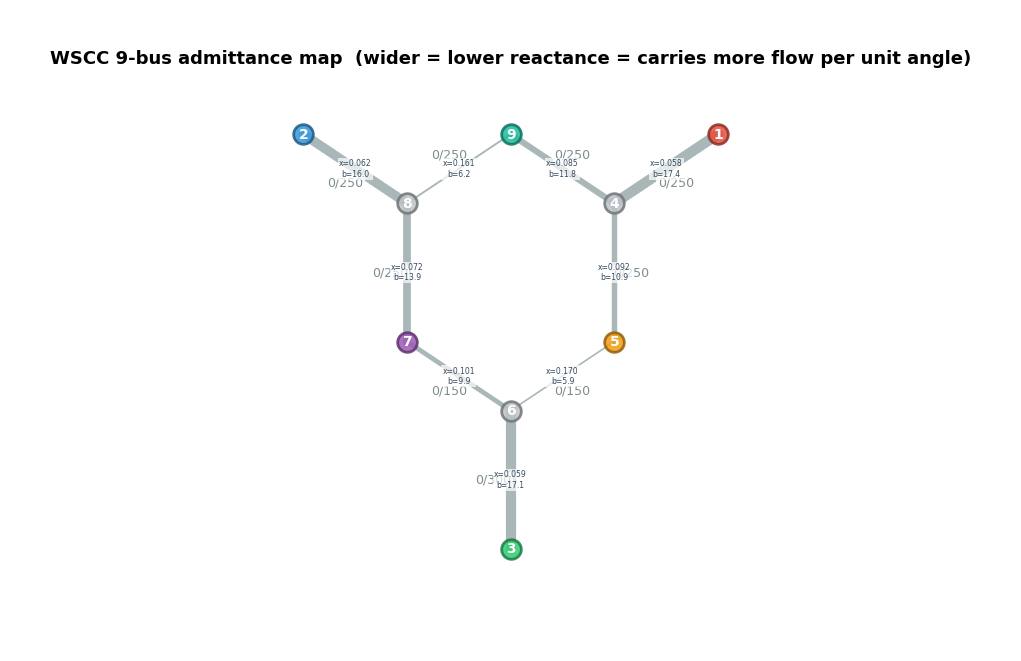

,x (reactance),b = 1/x,draw width
line_0 (1-4),0.0576,17.36,7.50
line_3 (3-6),0.0586,17.06,7.34
line_6 (8-2),0.0625,16.00,6.75
line_5 (7-8),0.0720,13.89,5.59
line_8 (9-4),0.0850,11.76,4.43
line_1 (4-5),0.0920,10.87,3.94
line_4 (6-7),0.1008,9.92,3.42
line_7 (8-9),0.1610,6.21,1.38
line_2 (5-6),0.1700,5.88,1.20


In [5]:
pt = compute_ptdf(build_network(), slack_bus='1')
widths = susceptance_widths(pt, wmin=1.2, wmax=7.5)   # {line: linewidth} from b = 1/x

# Colour the nodes with the SAME per-bus palette used throughout the notebook:
# gen/load buses take their palette colour, pure transit buses stay grey. The
# membership comes from the fleet (not the dispatch), so these node colours match
# the dispatched figures exactly -- this is purely a susceptance map, no flows.
node_colors = BUS_COLORS   # canonical per-bus palette (defined with pt above)

# Pure susceptance map: no dispatch annotations, no flows -- width encodes
# admittance only, nodes carry the standard palette colour.
fig, ax = plot_network_topology(
    build_network(), supply_by_bus={}, demand_by_bus={},
    bus_colors=node_colors, bus_coords=COORDS,
    line_flows={l: 0.0 for l in pt.lines},   # 0 flow -> no arrows, grey lines
    line_widths=widths,
    title='WSCC 9-bus admittance map  (wider = lower reactance = carries more flow per unit angle)',
)
# annotate each line with its x and b
for l, (b0, b1) in zip(pt.lines, pt.line_buses):
    x0, y0 = COORDS[b0]; x1, y1 = COORDS[b1]
    xm, ym = (x0 + x1) / 2, (y0 + y1) / 2
    b = pt.susceptance[pt.line_idx[l]]
    ax.text(xm, ym, f'x={1/b:.3f}\nb={b:.1f}', fontsize=5.5, ha='center', va='center',
            color='#34495E', bbox=dict(fc='white', ec='none', alpha=0.7, pad=0.8), zorder=6)
plt.show()

pd.DataFrame({
    'x (reactance)': [round(1 / pt.susceptance[pt.line_idx[l]], 4) for l in pt.lines],
    'b = 1/x': [round(pt.susceptance[pt.line_idx[l]], 2) for l in pt.lines],
    'draw width': [round(widths[l], 2) for l in pt.lines],
}, index=[f'{l} ({a}-{b})' for l, (a, b) in zip(pt.lines, pt.line_buses)]).sort_values('b = 1/x', ascending=False)

## 2. Market engine and nodal dispatch

### The dispatch each engine solves, its Lagrangian, and the bus prices

`solve_engine_dispatch` clears **one engine's** DC-OPF on the shared network: a
bid-based security-constrained economic dispatch (SCED) reduced to a **single
period with energy-cost bids only** (no unit commitment) and a **single
system-wide energy balance**. An engine $M$ brings its resources $\mathcal R^M$
(cost $c_i$, cap $\bar g_i$ at bus $\mathrm{bus}(i)$), its served load $d^M_n$, an
activated line set $\mathcal M^M_{\mathrm{act}}$, and any **exogenous** cross-footprint
schedule $\mathrm{exo}^M_n$ (zero for a stand-alone clear).

**Nomenclature.** Sets are script capitals; an element is the matching
lower-case letter (upper-case for markets).

| Symbol | Definition |
|---|---|
| $\mathcal N$ | the set of buses in the network; $n\in\mathcal N$ |
| $\mathcal M$ | the set of monitored lines (network constraints); $m\in\mathcal M$ |
| $\mathcal E$ | the set of market engines operating on the shared network; $M\in\mathcal E$ |
| $\mathcal R^M$ | the set of resources (generators) cleared by market $M$; $i\in\mathcal R^M$ |
| $\mathcal M^M_{\mathrm{act}}\subseteq\mathcal M$ | the lines whose limits market $M$ activates (enforces) in its clearing |
| $c_i,\ \bar g_i,\ \mathrm{bus}(i)$ | marginal cost, capacity, and host bus of resource $i$ |
| $g_i$ | dispatch of resource $i$ — the engine's decision variable, $0\le g_i\le\bar g_i$ |
| $d^M_n$ | load served by market $M$ at bus $n$ (zero wherever $M$ serves no load) |
| $SF_{n,m}$ | shift factor of bus $n$ on line $m$ |
| $\bar F_m$ | operating limit of line $m$ |
| $\mathrm{exo}^M_n$ | exogenous scheduled injection at bus $n$ in market $M$'s clear (fixed before it runs) |
| $u_n$ | unserved (shed) load at bus $n$ — the relaxation variable, $0\le u_n\le d^M_n$ (zero unless the relaxation is enabled) |
| $V$ | load-shed penalty price, \$/MWh (`SHED_PRICE`; the engine's `shed_price`) |

Case carries meaning here: lower-case $m$ indexes a **line**, upper-case $M$
names a **market engine** drawn from $\mathcal E$, and script $\mathcal M$ is
the set of lines — three different objects. The formulation is written for a
general $M\in\mathcal E$; the unified clearing of this section is the special
case where $\mathcal E$ has a single member spanning every bus.


**Objective — minimise the engine's own dispatch cost.**

$$\min_{0\le g_i\le \bar g_i}\ \ C^M=\sum_{i\in\mathcal R^M} c_i\,g_i. \qquad\qquad(1)$$

*In words.* Stack up the engine's own generators cheapest-first to cover its obligation
(no-load, start-up and shut-down terms drop out in this single-period, energy-only cut).

**Energy balance — its dual is the energy price $\lambda^M$.**

$$\sum_{i\in\mathcal R^M} g_i=\sum_{n\in\mathcal N} d^M_n-\sum_{n\in\mathcal N} \mathrm{exo}^M_n,\   \ [\lambda^M]\qquad\qquad(2)\quad$$

*In words.* The engine's generation serves its own load net of any scheduled interchange:
$\mathrm{exo}^M_n>0$ is power injected into the footprint (an import), $\mathrm{exo}^M_n<0$ a
withdrawal (an export). $\lambda^M$ is the single system-wide energy price (`res.energy_price`). Note the
**market scoping sits on the data, not the bus set**: the sums run over every bus
$n\in\mathcal N$, but $d^M_n$ vanishes wherever $M$ serves no load, and $\mathrm{exo}^M_n$
may sit at *any* bus of the shared network.

**Feasibility relaxation — load shedding at a penalty.** Constraint (2) can be
impossible to satisfy — load behind a binding line with too little reachable
generation — and a market clearing must not simply fail. The engine therefore
carries an **opt-in power-balance relaxation** (`shed_price`; the `# -- EDIT --`
cell below sets `SHED_PRICE = 150` \$/MWh): every load bus gains an
unserved-load variable $u_n$, penalised in the objective and netted from the
load it relaxes,

$$\min\ \sum_{i\in\mathcal R^M} c_i\,g_i+V\!\sum_{n\in\mathcal N} u_n,\qquad
  \sum_{i\in\mathcal R^M} g_i=\sum_{n\in\mathcal N}\big(d^M_n-u_n\big)-\sum_{n\in\mathcal N}\mathrm{exo}^M_n,\qquad
  0\le u_n\le d^M_n,$$

with every flow built from the **served** load $d^M_n-u_n$. Mechanically $u_n$
is a virtual generator at the load bus with cost $V$: nothing sheds while
cheaper supply can still reach the bus, and wherever shedding is interior the
bus price is exactly $\lambda^M_n=V$ — the relaxation penalty doubles as the
price cap. (EDAM relaxes each BAA's power balance the same way: energy
supply-shortfall variables priced at penalty costs in the objective.) The
equations below are written without $u_n$; in every worked example the
relaxation is enabled but slack ($u_n=0$ throughout).

**Flow and activated limits — duals $\mu^M_m$.**

$$F^M_m=\sum_{n\in\mathcal N} SF_{n,m}\,p^{\mathrm{inj},M}_n\ \ (m\in\mathcal M),\qquad
  -\bar F_m\le F^M_m\le \bar F_m\ \ [\mu^M_m]\ \ (m\in\mathcal M^M_{\mathrm{act}}),\qquad
  p^{\mathrm{inj},M}_n=\!\!\!\sum_{i\in\mathcal R^M:\,\mathrm{bus}(i)=n}\!\!\!g_i-d^M_n+\mathrm{exo}^M_n\ \ (n\in\mathcal N). \qquad(3)$$

*In words.* The engine's flow on a line is the shift-factor-weighted sum of **its own** net
injections, held within the rating **only on the lines it activates**. A line outside
$\mathcal M^M_{\mathrm{act}}$ has its limit relaxed and stays silent (`activated_lines`).

**The Lagrangian.**

$$\mathcal L^M(g,\lambda^M,\mu^M,\underline\mu^M,\overline\mu^M)=\sum_{i\in\mathcal R^M} c_i\,g_i-\lambda^M\!\Big(\sum_{i\in\mathcal R^M} g_i-\sum_{n\in\mathcal N} d^M_n+\sum_{n\in\mathcal N}\mathrm{exo}^M_n\Big)-\!\!\sum_{m\in\mathcal M^M_{\mathrm{act}}}\!\!\mu^M_m\,F^M_m+\sum_{i\in\mathcal R^M}\overline\mu^M_i\,(g_i-\bar g_i)-\sum_{i\in\mathcal R^M}\underline\mu^M_i\,g_i. \qquad(4)$$

*In words.* Cost, minus the energy-balance multiplier times the imbalance, minus each activated
line's (signed) congestion multiplier times the flow on it, plus one multiplier per generator
capacity limit: $\overline\mu^M_i\ge 0$ on the upper limit $g_i\le\bar g_i$ and
$\underline\mu^M_i\ge 0$ on the lower limit $g_i\ge 0$. $\lambda^M$ and the $\mu^M_m$ are exactly
`res.energy_price` and `res.line_dual`.

**Complementary slackness.** Each capacity multiplier is non-zero only when its own limit binds:

$$\overline\mu^M_i\,(g_i-\bar g_i)=0,\qquad \underline\mu^M_i\,g_i=0,\qquad \overline\mu^M_i,\underline\mu^M_i\ge 0,\qquad \forall\,i\in\mathcal R^M.$$

A fully-loaded unit ($g_i=\bar g_i$) may carry $\overline\mu^M_i>0$, an idle unit ($g_i=0$) may
carry $\underline\mu^M_i>0$, and a **marginal** unit ($0<g_i<\bar g_i$) has both equal to zero.

**Stationarity — where the price comes from.** At the optimum the Lagrangian is stationary in
each dispatch variable. For a generator $i$ at bus $n=\mathrm{bus}(i)$, using $\partial F^M_m/\partial g_i=SF_{n,m}$:

$$\frac{\partial \mathcal L^M}{\partial g_i}
  = c_i-\lambda^M-\!\!\sum_{m\in\mathcal M^M_{\mathrm{act}}}\!\!SF_{n,m}\,\mu^M_m\;+\;\overline\mu^M_i-\underline\mu^M_i\;=\;0 .$$

For a **marginal** unit the two bound multipliers vanish by complementary slackness, so the
$\overline\mu^M_i-\underline\mu^M_i$ term drops and we are left with
$c_i=\lambda^M+\sum_{m}SF_{n,m}\,\mu^M_m$.

**Nodal LMP — the price at every bus.**

$$\lambda^M_n=\lambda^M+\sum_{m\in\mathcal M^M_{\mathrm{act}}}SF_{n,m}\,\mu^M_m\ \ (n\in\mathcal N). \qquad\qquad(5)$$

*In words.* A bus's price is the system energy price plus, for every binding activated line, that
line's shadow price scaled by the bus's shift factor onto it. With nothing binding, every bus
collapses to the one price $\lambda^M$. **Section 2 runs the unified counterfactual**: a single
engine over **all** buses with $\mathrm{exo}=0$ and every limit enforced — the single-price
benchmark the rest of the notebook builds on.

### Congestion rent

Unified clearing is the single engine over **all** buses ($\mathrm{exo}=0$, every
line activated), so we drop the engine superscript: write $\lambda_n\equiv\lambda^M_n$,
$\mu_m\equiv\mu^M_m$, $d_n\equiv d^M_n$, and $\mathcal M_{\mathrm{act}}$ for the activated set; let
$g_n=\sum_{i:\,\mathrm{bus}(i)=n} g_i$ be the dispatch at bus $n$. Value each binding
line's limit at its shadow price — equivalently, net the bus-level payments:

$$R=\sum_{m\in\mathcal M_{\mathrm{act}}}|\mu_m|\,|F_m|
   =\underbrace{\sum_{n\in\mathcal N}\lambda_n d_n}_{\text{paid by load}}
   -\underbrace{\sum_{n\in\mathcal N}\lambda_n g_n}_{\text{paid to generation}}. \qquad (6)$$

*In words.* The congestion rent (merchandising surplus) is the shadow price of each binding
line times the power on it — and it equals exactly what load pays minus what generation is
paid, because the energy components net to zero (total generation $=$ total load). **No
binding line $\Rightarrow$ no price separation $\Rightarrow R=0$.** 

**Edit below:** generator costs, load levels, and line ratings. Limiting a line rating may
create congestion and price separation on the constrained
path.

In [6]:
# -- EDIT -- unified-clearing inputs --------------------------------------
COST_OVERRIDE   = {}                      # e.g. {'gen_0': 45.0} to re-bid the $35 unit
LOAD_OVERRIDE   = {}                      # e.g. {'7': 130.0}
LINE_RATINGS    = {'line_4': 40.0, 'line_1': 30.0, 'line_2': 30.0}   # adjust line_4 (6-7, internal to BA-1) below its ~63 MW natural flow
SHED_PRICE      = 150.0   # $/MWh -- load-shed (power-balance relaxation) penalty; None disables
# -------------------------------------------------------------------------

net = build_network(LINE_RATINGS)
pt  = compute_ptdf(net, slack_bus='1')

unified = make_engine('UNIFIED', buses=pt.buses)
for g, c in COST_OVERRIDE.items(): unified.gens[g]['cost'] = c
for b, v in LOAD_OVERRIDE.items(): unified.loads[b] = v

res = solve_engine_dispatch(pt, unified, shed_price=SHED_PRICE)
print('dispatch (MW):', {k: round(v, 1) for k, v in res.dispatch.items()})
print('energy price :', round(res.energy_price, 2), '$/MWh')
binding = {k: round(v, 1) for k, v in res.line_dual.items() if abs(v) > 1e-3}
print('binding lines:', binding or 'none')
print('load shed    :', {b: round(v, 1) for b, v in res.shed_by_bus.items()} or 'none')
print()
print('LMP by bus ($/MWh):')
pd.Series({b: round(res.lmp[b], 2) for b in pt.buses}).to_frame('LMP').T

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


dispatch (MW):

{'gen_slack_0': 101.1, 'gen_0': 113.9, 'gen_1': 70.0}

energy price :

50.0

...

{'line_1': -94.4, 'line_2': 140.4, 'line_4': -4.5}

load shed    :

{'5': 30.0}

LMP by bus ($/MWh):

,1,2,3,4,5,6,7,8,9
LMP,50.0,35.0,20.0,50.0,150.0,20.0,30.61,35.0,44.82


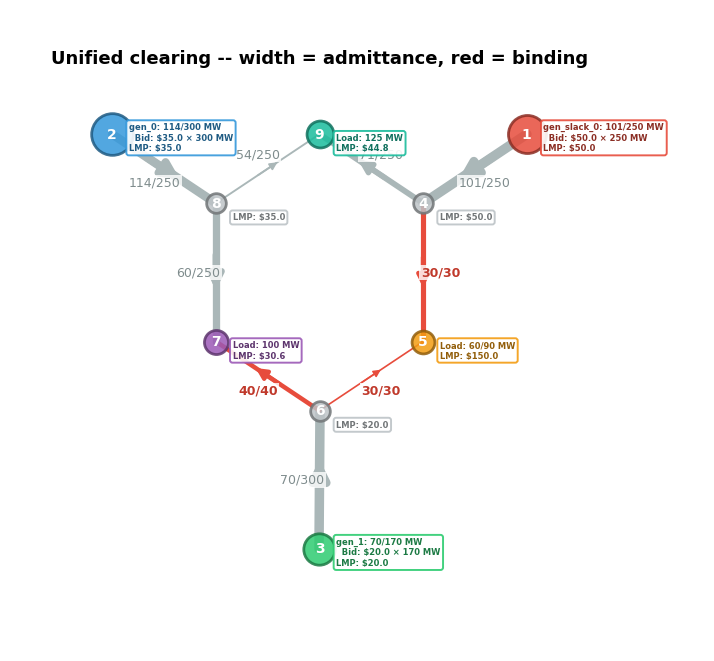

In [7]:
# Topology with DC power flow. Line WIDTH = susceptance (b=1/x); line COLOUR =
# congestion. A line is red only when its shadow price is non-zero (a genuine
# binding transmission limit) -- NOT merely when flow hits rating, which can
# happen because the generator behind a radial line is maxed out.
sup, dem = to_supply_demand(unified, res)
colors = dict(BUS_COLORS)   # canonical colours; a subset clearing no longer reshuffles them
flows = {l: res.flow_own[l] for l in pt.lines}
binding_lines = {l for l, mu in res.line_dual.items() if abs(mu) > 1e-3}
fig, ax = plot_network_topology(
    net, sup, dem, bus_colors=colors, bus_lmps=res.lmp, line_flows=flows,
    line_widths=susceptance_widths(pt), constrained_lines=binding_lines, bus_coords=COORDS,
    demand_served_by_bus=served_by_bus(res, dem),   # 'served/total' where load is shed
    title='Unified clearing -- width = admittance, red = binding',
)
plt.show()

### The nodal dispatch diagram, and the congestion shadow price

The **nodal dispatch diagram** (a circlize / chord chart), built here from the unified DC-OPF. Each sector is a bus. The bar's height for a generator is that unit's marginal cost (its bid) -- solid
where dispatched, faded where it is available capacity. A **dashed line is drawn across each
bus at its cleared LMP**; the gap between a dispatched bar's top and that line is the unit's
**inframarginal rent** (LMP - marginal cost), while a bar rising *above* the line is out of
merit at this price and stays undispatched. The bar's height for a demand bus is drawn at LMP height, and the
**chords** are PTDF-traced generator→load deliveries. Below the figure we print the
congestion shadow price $\mu_m$ on each binding line — the dual of the binding-line
limit, and the exact quantity that splits the LMPs through $\sum_m SF_{n,m}\,\mu_m$.

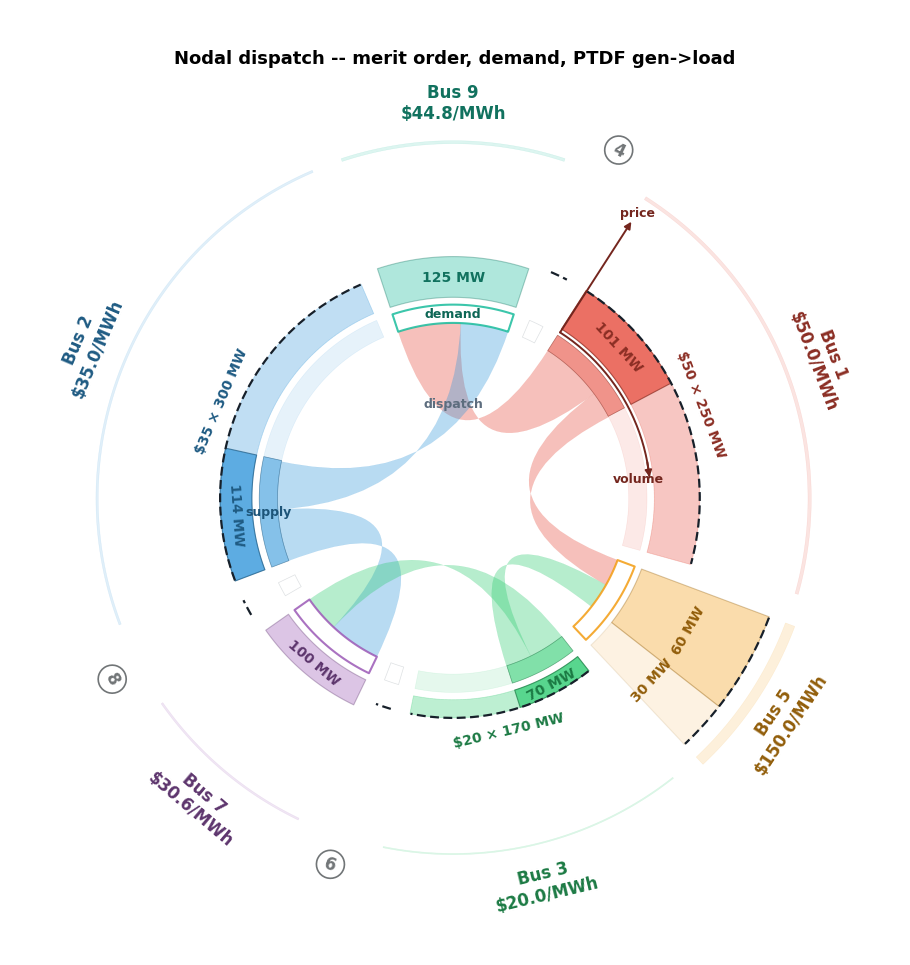

Binding transmission constraints -- congestion shadow price |mu_m|:

  line_2 (5-6): |mu| = $140.37/MWh   (flow -30 MW at the 30 MW limit)

  line_1 (4-5): |mu| = $94.39/MWh   (flow +30 MW at the 30 MW limit)

  line_4 (6-7): |mu| = $4.46/MWh   (flow +40 MW at the 40 MW limit)


Settlement by node  (payments to generation vs payments by load):

...

Revenue adequacy is preserved by reducing the load SERVED, not by relaxing a line or serving unpaid load: shed load pays nothing, so paid-by-load - paid-to-gen still equals the line congestion rent exactly. The shed penalty (SHED_PRICE x MW) is an objective-function term -- the value of lost load -- not a settlement cash flow.


Marginal value of line capacity  (shadow price x flow, per line):

,from,to,flow (MW),rating (MW),binding,|mu| ($/MWh = value of +1 MW),rent |mu| x flow ($/h)
line,,,,,,,
line_0,1,4,101.1,250.0,False,0.0,0.0
line_1,4,5,30.0,30.0,True,94.39,2831.7
line_2,5,6,-30.0,30.0,True,140.37,4211.0
line_3,3,6,70.0,300.0,False,0.0,0.0
line_4,6,7,40.0,40.0,True,4.46,178.5
line_5,7,8,-60.0,250.0,False,0.0,0.0
line_6,8,2,-113.9,250.0,False,0.0,0.0
line_7,8,9,53.9,250.0,False,0.0,0.0
line_8,9,4,-71.1,250.0,False,0.0,0.0


The |mu| column is the value of relaxing each line by 1 MW; only binding lines carry a positive value.
The rent column decomposes the congestion rent above by line and totals $7,221.2/h.


wrote seams_settlement_by_node.csv  and  seams_line_capacity_value.csv  to  C:\Users\docke\Projects\ASSUME\assume\testbed

In [8]:
# Nodal dispatch diagram (circlize / chord) of the unified clearing (reuses sup, dem, colors, res from above).
flow_list = nodal_plot.compute_ptdf_flows(net, sup, served_demand(res, dem))   # PTDF-traced gen->load chords (on SERVED load)

fig = plot_nodal_circlize(
    sup, dem, pt.buses,
    flows=flow_list,
    clearing_price=res.energy_price,
    bus_lmps=res.lmp,
    bus_colors=colors,
    demand_segments=shed_segments(res, dem),   # faint tail (bus colour) = shed (unserved) load
    lmp_line=True,   # dashed line = bus LMP; solid bar height = unit marginal cost (gap = inframarginal rent)
    annotate_roles=True,   # one-time supply/demand/transfers key near 12 o'clock
    axis_key=True,         # illustrative price (up) / volume (across) L-axis in the corner
    sector_order=RING_ORDER,   # clockwise from 12 o'clock, following the network ring
    center_bus=CENTER_BUS,     # bus 9 centred at 12 o'clock (matches the rotated node diagram)
    figsize=(8.5, 9.0),        # fills the width of an 8.5x11 page (extra height -> title headroom)
    label_fontsize=12,         # outer sector labels (Bus N / LMP)
    track_fontsize=10,         # in-track bid / dispatch / load-MW labels, >= 10 pt
    show_legend=False,         # per-bus gen/load/LMP already on the ring + in-track; legend was sub-10 pt and duplicative
    title='Nodal dispatch -- merit order, demand, PTDF gen->load',
)
plt.show()

# Shadow price of the binding line constraint(s): the congestion dual mu_m.
binding = {l: mu for l, mu in res.line_dual.items() if abs(mu) > 1e-3}
if binding:
    print('Binding transmission constraints -- congestion shadow price |mu_m|:')
    for l, mu in sorted(binding.items(), key=lambda kv: -abs(kv[1])):
        i = pt.line_idx[l]; a, b = pt.line_buses[i]
        print(f'  {l} ({a}-{b}): |mu| = ${abs(mu):.2f}/MWh   '
              f'(flow {res.flow_own[l]:+.0f} MW at the {pt.s_nom[i]:.0f} MW limit)')
else:
    print('No binding line constraints -- every bus collapses to the single energy price.')

# ── Settlement accounting: payments by node, subtotals, congestion rent ──────
# Convention: "paid to gen" is cash IN to generators (LMP x dispatch); "paid by
# load" is cash OUT from loads (LMP x demand). The system operator collects the
# difference as congestion rent / merchandising surplus -- and that residual
# equals the shadow-price money  sum_m |mu_m| * F_m  (the price-difference rent).
settle = pd.DataFrame(
    [{'bus': b,
      'LMP ($/MWh)': round(res.lmp[b], 2),
      'gen (MW)': round(res.gen_by_bus.get(b, 0.0), 1),
      'paid to gen ($/h)': round(res.lmp[b] * res.gen_by_bus.get(b, 0.0), 1),
      'load (MW)': round(unified.loads.get(b, 0.0), 1),
      'served (MW)': round(unified.loads.get(b, 0.0) - res.shed_by_bus.get(b, 0.0), 1),
      'paid by load ($/h)': round(res.lmp[b] * (unified.loads.get(b, 0.0)
                                                - res.shed_by_bus.get(b, 0.0)), 1)}
     for b in pt.buses]
).set_index('bus')

# Settle on SERVED load: shed (unserved) load consumes nothing and pays nothing.
gen_rev  = settle['paid to gen ($/h)'].sum()    # subtotal: total to generation
load_pay = settle['paid by load ($/h)'].sum()   # subtotal: total from served load
settle.loc['SUBTOTAL'] = ['', settle['gen (MW)'].sum(), gen_rev,
                          settle['load (MW)'].sum(), settle['served (MW)'].sum(), load_pay]

print('\nSettlement by node  (payments to generation vs payments by load):')
display(settle)

cong_rent = load_pay - gen_rev
mu_money  = sum(abs(mu) * abs(res.flow_own[l]) for l, mu in binding.items())
print(f'Congestion rent  =  paid by load  -  paid to gen  '
      f'=  {load_pay:,.1f}  -  {gen_rev:,.1f}  =  ${cong_rent:,.1f}/h')
print(f'Shadow-price check:  sum_m |mu_m| * F_m over binding lines  =  ${mu_money:,.1f}/h')
print('(equal by the LMP decomposition: the energy component nets to zero because '
      'total generation = total SERVED load,\n so only the congestion term survives, and it equals mu x flow on each binding line.)')

# Load shedding (power-balance relaxation): if any load is unserved, settlement
# is on SERVED load, so the rent identity above still balances -- revenue
# adequacy holds with NO relaxed line limits and NO unpaid phantom load.
_shed_total = sum(res.shed_by_bus.values())
if _shed_total > 1e-6:
    _where = ', '.join(f'bus {b} {u:.0f} MW' for b, u in res.shed_by_bus.items())
    print(f'\nLoad shed: {_shed_total:.0f} MW unserved ({_where}), each shed bus priced at '
          f'SHED_PRICE = ${SHED_PRICE:.0f}/MWh (its LMP -- the relaxation penalty is the price cap).')
    print('Revenue adequacy is preserved by reducing the load SERVED, not by relaxing a line or '
          'serving unpaid load: shed load pays nothing, so paid-by-load - paid-to-gen still equals '
          'the line congestion rent exactly. The shed penalty (SHED_PRICE x MW) is an '
          'objective-function term -- the value of lost load -- not a settlement cash flow.')

# ── Marginal value of line capacity: shadow price x flow, per line ───────────
# |mu_m| is the $/MWh fall in system cost from +1 MW of rating on line m (zero
# unless the line binds) -- the marginal value of capacity. |mu_m| x flow is the
# congestion rent that line collects; the column sums to the total rent above.
lines_tbl = pd.DataFrame(
    [{'line': l,
      'from': pt.line_buses[pt.line_idx[l]][0],
      'to': pt.line_buses[pt.line_idx[l]][1],
      'flow (MW)': round(res.flow_own[l], 1),
      'rating (MW)': round(pt.s_nom[pt.line_idx[l]], 0),
      'binding': abs(res.line_dual[l]) > 1e-3,
      '|mu| ($/MWh = value of +1 MW)': round(abs(res.line_dual[l]), 2),
      'rent |mu| x flow ($/h)': round(abs(res.line_dual[l]) * abs(res.flow_own[l]), 1)}
     for l in pt.lines]
).set_index('line')
lines_tbl.loc['TOTAL'] = ['', '', '', '', '', '',
                          round(lines_tbl['rent |mu| x flow ($/h)'].sum(), 1)]

print('\nMarginal value of line capacity  (shadow price x flow, per line):')
display(lines_tbl)
print('The |mu| column is the value of relaxing each line by 1 MW; only binding '
      'lines carry a positive value.\nThe rent column decomposes the congestion '
      f'rent above by line and totals ${lines_tbl.loc["TOTAL", "rent |mu| x flow ($/h)"]:,.1f}/h.')

# ── Export both tables to CSV (overwritten every run) for the Word write-up ──
settle.to_csv('seams_settlement_by_node.csv')
lines_tbl.to_csv('seams_line_capacity_value.csv')
print(f'\nwrote seams_settlement_by_node.csv  and  seams_line_capacity_value.csv  to  {os.getcwd()}')

### Composite figure 

The network diagram and the nodal dispatch diagram laid out side by side,
sized so the fonts stay clean at half-page width:

- node numbers sit in small chips **beside** each bubble (the coloured marker stays
  uncluttered); only the **LMP** is printed at each bus — the gen/bid/load detail
  lives in the nodal dispatch panel, so nothing is duplicated;
- on each bus sector the **bid** sits *outside / on top of* the gen bar and the
  **dispatched MW** sits *inside* it (mirroring the load bar, which prints its MW
  in-track); in-track labels are placed by bar height so they stay inside the bar;
- saved as a PNG and a vector PDF, overwritten each run.

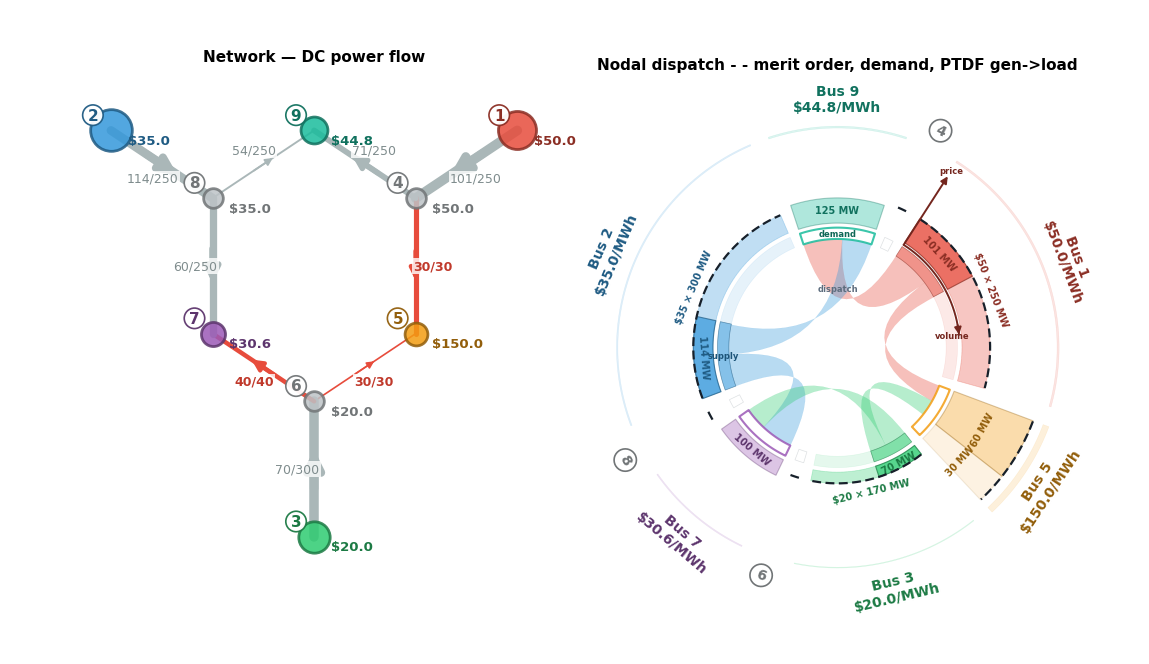

wrote cra_combined_figure.png (600 dpi) and cra_combined_figure.pdf to C:\Users\docke\Projects\ASSUME\assume\testbed

In [9]:
from nodal_plot import plot_combined_letter

binding_lines = {l for l, mu in res.line_dual.items() if abs(mu) > 1e-3}
fig, (ax_net, ax_circ) = plot_combined_letter(
    net, sup, dem,
    bus_colors=colors, bus_lmps=res.lmp,
    line_flows={l: res.flow_own[l] for l in pt.lines},
    line_widths=susceptance_widths(pt), constrained_lines=binding_lines,
    flows=nodal_plot.compute_ptdf_flows(net, sup, served_demand(res, dem)),
    clearing_price=res.energy_price,
    demand_segments=shed_segments(res, dem),   # faint tail (bus colour) = shed (unserved) load
    lmp_line=True,   # dashed line = bus LMP; solid bar height = unit marginal cost
    annotate_roles=True,   # one-time supply/demand/transfers key near 12 o'clock
    axis_key=True,         # illustrative price (up) / volume (across) L-axis in the corner
    all_buses=pt.buses, sector_order=RING_ORDER,
    bus_coords=COORDS, center_bus=CENTER_BUS,   # rotated node diagram + bus 9 at 12 o'clock
    title_right='Nodal dispatch - - merit order, demand, PTDF gen->load',
)
fig.savefig('cra_combined_figure.png', dpi=600, bbox_inches='tight')
fig.savefig('cra_combined_figure.pdf', bbox_inches='tight')   # vector, for Word
plt.show()
print(f'wrote cra_combined_figure.png (600 dpi) and cra_combined_figure.pdf to {os.getcwd()}')

**Read it:** with `line_4` (6–7) limited to 40 MW, the binding internal limit
splits the LMPs — the bus-7 load behind the constraint prices up to ~\$37 while the
cheap bus-3 pocket (\$20) stays low. The congestion term is exactly
$\sum_m SF_{n,m}\,\mu_m$; set `LINE_RATINGS = {}` and re-run to collapse every bus
back to a single energy price.

## 3. Two balancing authorities on the shared network

The same 9-bus nodal network, now configured as **two balancing authorities** that
co-optimise a single dispatch but settle separately. The partition is an
*accounting overlay* on the unified clearing of Section 2 — the physics and the
LMPs are unchanged; the new question is **where the congestion revenue lands**.

This partition leaves **exactly two tie lines** (interconnectors) whose ends sit
in different BAs: `line_2` (5-6) and `line_7` (8-9). Every other line is internal
to one BA. The partition assigns every **bus** to exactly one BA; it does **not**
assign the lines. Which BA *manages* each line is a separate, **configurable**
choice — the `BA_LINES` lists in the config cell, where **every line is placed
explicitly** and any line may be moved to either BA. The natural default lists
each line under the BA containing both its ends; the two ties are then placed
too: `line_2` under **BA-1** and `line_7` under **BA-2**. A line listed under
*neither* BA draws **grey** and its rent is split between them.

*Reading the figures below.* Lines are **coloured by the BA that manages them** (BA-1 purple, BA-2 blue); a line assigned to **neither** BA draws **grey**, and any line that turns **bright red** is congested (a binding limit), which overrides its BA colour. On the nodal dispatch (chord) diagram each BA's arc carries a matching **outer band and label**, and a **dashed line on each generator marks its bus LMP** over the marginal-cost fill -- the gap is that unit's inframarginal rent.

In [10]:
# Section 3 config: the two balancing authorities 
BA_DEFS = {
    'BA-1': ['2', '8', '7', '6', '3'],   # the cheap fleet (bus 3 $20, bus 2 $35); load at 7 -> net exporter
    'BA-2': ['1', '9', '4', '5'],         # only the bus-1 unit ($50); loads at 5 and 9 -> net importer
}
# -- EDIT -- the lines each BA manages. Any line may be listed under either BA;
# a line listed under neither is unassigned: grey on figures, rent split 50/50.
# Natural default: each BA takes the lines with both ends in its footprint; the
# two ties (5-6, 8-9) are then placed explicitly.
BA_LINES = {
    'BA-1': ['line_2', 'line_3', 'line_4', 'line_5', 'line_6'],   # line_2 = tie 5-6
    'BA-2': ['line_0', 'line_1', 'line_7', 'line_8'],             # line_7 = tie 8-9
}
BA_COLORS = {'BA-1': "#993AFF", 'BA-2': '#2471A3'}

bus_to_ba = {str(b): ba for ba, buses in BA_DEFS.items() for b in buses}
ba_of = lambda b: bus_to_ba.get(str(b))   # None -> the bus sits outside both BAs (non-market)
LOADS_ALL = dict(LOADS)   # {'5': 90, '7': 100, '9': 125}

def line_kind(pt, l):
    # ('internal', ba): both ends in one BA | ('tie', None): ends in two
    # DIFFERENT BAs | ('boundary', None): one end outside both BAs (non-market).
    # Topological, fixed by the bus partition; independent of BA_LINES.
    i = pt.line_idx[l]; b0, b1 = pt.line_buses[i]
    a0, a1 = ba_of(b0), ba_of(b1)
    if a0 is not None and a0 == a1:
        return ('internal', a0)
    if a0 is not None and a1 is not None:
        return ('tie', None)
    return ('boundary', None)

pt = compute_ptdf(build_network(), slack_bus='1')
ties = [l for l in pt.lines if line_kind(pt, l)[0] == 'tie']   # topological: ends in different BAs

# line -> managing BA, from the BA_LINES config above; unlisted -> None.
_owner = {}
for _ba, _ls in BA_LINES.items():
    for _l in _ls:
        assert _l in pt.lines, f'unknown line in BA_LINES: {_l}'
        assert _l not in _owner, f'{_l} listed under both {_owner[_l]} and {_ba}'
        _owner[_l] = _ba
LINE_BA = {l: _owner.get(l) for l in pt.lines}

# Settlement areas: the two BAs plus, if any bus sits outside both, a single
# 'Non-market' area. This notebook assigns every bus to a BA (AREAS == BA_DEFS);
# the methodology settles whatever areas exist -- rent is allocated to BAs only.
AREAS = {ba: [str(b) for b in buses] for ba, buses in BA_DEFS.items()}
_nm_buses = [b for b in pt.buses if b not in bus_to_ba]
if _nm_buses:
    AREAS['Non-market'] = _nm_buses

print('BA-1 buses:', BA_DEFS['BA-1'])
print('BA-2 buses:', BA_DEFS['BA-2'])
print('tie lines :', [f"{l} ({pt.line_buses[pt.line_idx[l]][0]}-{pt.line_buses[pt.line_idx[l]][1]})" for l in ties])
print('lines managed by BA-1:', [l for l in pt.lines if LINE_BA[l] == 'BA-1'])
print('lines managed by BA-2:', [l for l in pt.lines if LINE_BA[l] == 'BA-2'])
print('assigned to neither  :', [l for l in pt.lines if LINE_BA[l] is None])
print('non-market buses     :', _nm_buses or 'none (every bus in a BA)')

# -- BA line colours + group map (used by the BA map and every Section-3 figure)
def ba_line_colors(pt):
    # Each line takes its managing BA's colour (LINE_BA); unassigned lines grey.
    return {l: (BA_COLORS[LINE_BA[l]] if LINE_BA.get(l) else '#AAB7B8') for l in pt.lines}

BA_GROUPS = {b: ba_of(b) for b in pt.buses if ba_of(b)}   # circlize banding; non-market buses unbanded


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


BA-1 buses:

['2', '8', '7', '6', '3']

BA-2 buses:

['1', '9', '4', '5']

...

['line_0', 'line_1', 'line_7', 'line_8']

assigned to neither  :

[]

non-market buses     :

none (every bus in a BA)

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


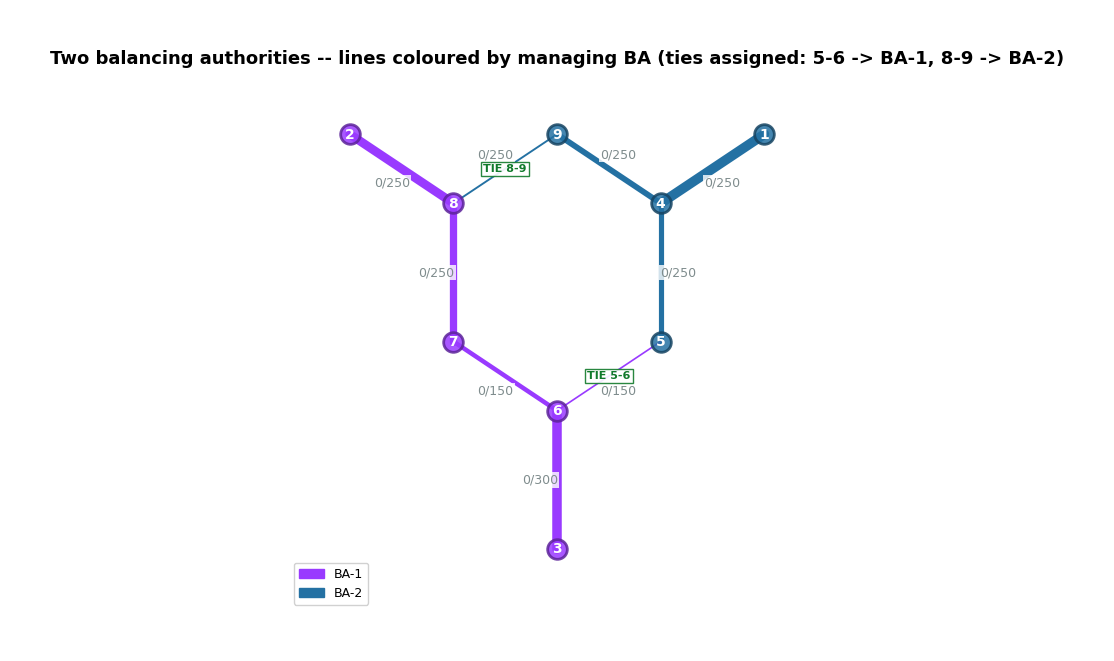

In [11]:
# Map of the two BAs and the interconnectors (buses coloured by BA).
ba_bus_colors = {b: BA_COLORS[ba_of(b)] for b in pt.buses}
fig, ax = plot_network_topology(
    build_network(), supply_by_bus={}, demand_by_bus={},
    bus_colors=ba_bus_colors, bus_coords=COORDS,
    line_flows={l: 0.0 for l in pt.lines}, line_widths=susceptance_widths(pt),
    line_colors=ba_line_colors(pt),   # lines coloured by the BA that manages them (LINE_BA); unassigned grey
    title='Two balancing authorities -- lines coloured by managing BA (ties assigned: 5-6 -> BA-1, 8-9 -> BA-2)',
)
for l in ties:
    i = pt.line_idx[l]; b0, b1 = pt.line_buses[i]
    x0, y0 = COORDS[b0]; x1, y1 = COORDS[b1]
    ax.text((x0+x1)/2, (y0+y1)/2, f'TIE {b0}-{b1}', fontsize=8, fontweight='bold',
            color='#117A2B', ha='center', va='center',
            bbox=dict(fc='white', ec='#117A2B', alpha=0.9, pad=1.5), zorder=7)
import matplotlib.patches as mpatches
ax.legend(handles=[mpatches.Patch(color=BA_COLORS[ba], label=ba) for ba in BA_DEFS],
          loc='lower left', fontsize=9, framealpha=0.9)
plt.show()

### Two allocation rules

The same rent $R$ from eq.&nbsp;(6), now split between the two BAs. First the per-BA
ledger, then the border term, then the two methods — each as an equation with a
plain-language reading.

**Per-BA ledger.** For BA $a$ with buses $\mathcal N_a$:

$$G_a=\sum_{n\in\mathcal N_a}\lambda_n g_n,\qquad
  L_a=\sum_{n\in\mathcal N_a}\lambda_n d_n,\qquad
  N_a=L_a-G_a,\qquad \sum_a N_a=R. \qquad (7)$$

*In words.* $G_a$ is what the BA's **generators are paid**, $L_a$ what its **loads pay**, and
$N_a$ its **net payment into the congestion pool**. The two BAs' net payments sum to the whole
rent $R$ — congestion is a transfer from net-paying areas to net-receiving ones. Buses
outside both BAs — a **non-market area** — settle the same way and join the
sum: they pay or are paid at LMP but are never *allocated* rent, and the
ledgers grow a matching column. (`ba_settlement`: `gen_rev`, `load_pay`,
`net_into_pool`; areas come from `AREAS` in the Section-3 config.)

**Rent by line assignment.** Each line is **assigned** to at most one BA — a
configurable choice (the `BA_LINES` lists), not a consequence of the bus partition.
$\mathcal M_a$ is the set of lines assigned to BA $a$ and $\mathcal M_{\emptyset}$
the unassigned remainder. By default a line with both ends in BA $a$ is assigned
to it; here the two ties are also assigned — `line_2` to BA-1, `line_7` to BA-2 —
so $\mathcal M_{\emptyset}$ is empty:

$$R=R^{\emptyset}+\sum_a R_a,\qquad
  R_a=\!\!\sum_{m\,\in\,\mathcal M_a}\!\!|\mu_m F_m|,\qquad
  R^{\emptyset}=\!\!\sum_{m\,\in\,\mathcal M_{\emptyset}}\!\!|\mu_m F_m|. \qquad (8)$$

*In words.* Split the total rent by **which BA manages the binding line**. A line assigned to
BA $a$ feeds $R_a$; rent on lines assigned to neither BA pools in $R^{\emptyset}$.
(`line_rent_table`, `BA_LINES`.)

**Cross-border separation rent.** A **tie** is a line whose ends sit in different
BAs — the set $\mathcal M^{\mathrm{tie}}$. This is *topological* (fixed by the bus
partition), independent of the management assignment above: assigning `line_2` to
BA-1 does not stop it crossing the border. On each tie $m$ from $b_0$ to $b_1$
carrying flow $F_m$, price the cross-border gap from its **causes** — the binding
line constraints, through their shift factors — not by reading the raw nodal gap
off the solution:

$$\Delta\lambda^{\mathrm{cong}}_m=\!\!\sum_{m'\in\mathcal M_{\mathrm{act}}}\!\!\big(SF_{b_1,m'}-SF_{b_0,m'}\big)\,\mu_{m'},\qquad
\tau=\sum_{m\,\in\,\mathcal M^{\mathrm{tie}}}\big|\,\Delta\lambda^{\mathrm{cong}}_m\,F_m\,\big|. \qquad (9)$$

*In words.* Each binding line's shadow price reaches the tie's two ends with
different leverage; the shift-factor difference times $\mu_{m'}$ adds up exactly
the price gap **that line congestion creates** across the border, and $\tau$ values
the crossing power at that gap — what the importing BA's load pays *above* what
the exporting BA's generation receives, for the energy that crosses. By eq. (5)
this *equals* the raw gap $\lambda_{b_1}-\lambda_{b_0}$ whenever line limits are
the only binding constraints (as here), but the two part ways in Section 4, where
a transfer constraint separates prices for a different reason with its own revenue
stream — built this way, $\tau$ collects only the congestion-caused piece, every
dollar of it traceable to a binding line of eq. (8). It is also how the congestion
component of a nodal price is formed in practice: shift factors times constraint
shadow prices, never a price difference read between two nodes. This is the piece
of the rent the border itself creates, and the piece Method&nbsp;2 reassigns.
(`border_separation`: `dlam_cong`, `sep_rent`.)

---

**Method&nbsp;1 — the constraint's home BA keeps its full rent.**

$$A^{(1)}_a=R_a+\tfrac12\,R^{\emptyset}. \qquad (10)$$

*In words.* Each BA banks the **full** $\mu_m\!\cdot\!F_m$ rent of every line **assigned
to it**; rent on unassigned lines is split 50/50 (none arise under the default assignment
here). An **internal** constraint's rent stays home **even when that constraint separated
prices in the other BA** — the rent follows the wire's assignment, not the price impact.
This is the full constraint revenue accruing only to the managing BA's settlement.

**Method&nbsp;2 — rebate the cross-border separation to the load that over-paid.**
Let $h=\operatorname*{arg\,max}_a N_a$ be the **net-payer** BA and $f$ the other:

$$A^{(2)}_h=A^{(1)}_h+\tau,\qquad A^{(2)}_f=A^{(1)}_f-\tau. \qquad (11)$$

*In words.* Start from Method&nbsp;1, then **move the border rent $\tau$** from the funding BA $f$
to the net-payer BA $h$ — the side whose loads over-paid because the constraint pulled their
price away from the generation serving them. This rebates the cross-border
generation$\to$load transfer to that BA (congestion-revenue rights to its consumers). Total
rent is conserved: $A^{(2)}$ still sums to $R$. The choice of $\tau$ and of the recipient is a
**v1 rule, written explicitly so it can be refined** (e.g. later split $\tau$ between
importer-load and exporter-gen).

---

**Two readings of each BA's outcome** (the bottom row of each ledger, built in `revenue_table` — one table per method):

$$\underbrace{P^{(k)}_a=A^{(k)}_a-N_a}_{\text{area net position}},
  \qquad\qquad
  \underbrace{\tilde L^{(k)}_a=L_a-A^{(k)}_a}_{\text{load cost net of CRR}}. \qquad (12)$$

*In words.* $P^{(k)}_a=0$ means method $k$ makes BA $a$ **whole** — its allocated rent exactly
offsets its net payment into the pool. $\tilde L^{(k)}_a$ is the BA's load bill **after** its
allocated rent is rebated to its own consumers as congestion-revenue rights — the number a
load-serving entity ultimately feels. In the ledgers below each BA's **consumers and
generators sit side by side** (cash out negative, cash in positive — the same
conventions as the autarky-vs-unified comparison closing this section), and the
bottom row carries both readings at once: the **Area net** column is $P^{(k)}_a$
and the **Consumer** column is $-\tilde L^{(k)}_a$. Comparing that row across the
Method&nbsp;1 and Method&nbsp;2 tables is the whole point of the exercise.

In [12]:
#  Methodology functions (edit these to refine the allocation rule) 
def ba_settlement(res, loads):
    """Per-AREA generator revenue (lmp*g) and SERVED-load payment (lmp*(d-u))
    at nodal LMPs. Areas = the two BAs plus, when buses sit outside both, a
    'Non-market' area -- it settles at LMP like any other (conservation needs
    its column) but is never allocated rent. Shed load pays nothing."""
    out = {}
    for area, buses in AREAS.items():
        gen_rev = sum(res.lmp[b] * res.gen_by_bus.get(b, 0.0) for b in buses)
        load_pay = sum(res.lmp[b] * (float(loads.get(b, 0.0)) - res.shed_by_bus.get(b, 0.0))
                       for b in buses)
        out[area] = dict(gen_rev=gen_rev, load_pay=load_pay, net_into_pool=load_pay - gen_rev)
    return out

def line_rent_table(res, pt):
    """Per-line congestion rent |mu|*|flow|, tagged by topology (internal/tie)
    and by the managing BA from the configurable LINE_BA assignment."""
    recs = []
    for l in pt.lines:
        i = pt.line_idx[l]; b0, b1 = pt.line_buses[i]
        mu, F = res.line_dual[l], res.flow_own[l]
        recs.append(dict(line=l, frm=b0, to=b1, kind=line_kind(pt, l)[0],
                         home=LINE_BA.get(l),
                         mu=round(mu, 2), flow=round(F, 1), rent=abs(mu) * abs(F)))
    return pd.DataFrame(recs).set_index('line')

def border_separation(res, pt):
    """Cross-border separation rent per tie, priced from its causes (eq. 9):
    dlam_cong = sum over binding lines of (SF at to-bus - SF at from-bus) * mu
    -- the part of the price gap that line congestion creates. dlam is the raw
    LMP gap for comparison, and dlam_xfer = dlam - dlam_cong is the part a
    binding transfer constraint creates (+/- mu_T; zero in this section),
    settled separately as transfer rent in Section 4. sep_rent prices the
    crossing flow at dlam_cong only."""
    recs = []
    for l in ties:
        i = pt.line_idx[l]; b0, b1 = pt.line_buses[i]
        F, dlam = res.flow_own[l], res.lmp[b1] - res.lmp[b0]
        dlam_cong = sum((pt.ptdf[pt.line_idx[m], pt.bus_idx[b1]]
                         - pt.ptdf[pt.line_idx[m], pt.bus_idx[b0]]) * mu
                        for m, mu in res.line_dual.items())
        imp = ba_of(b1) if F >= 0 else ba_of(b0)
        exp = ba_of(b0) if F >= 0 else ba_of(b1)
        recs.append(dict(line=l, flow=round(F, 1), dlam=round(dlam, 2),
                         dlam_cong=round(dlam_cong, 2),
                         dlam_xfer=round(dlam - dlam_cong, 2),
                         sep_rent=abs(dlam_cong * F), importing=imp, exporting=exp))
    return pd.DataFrame(recs).set_index('line')

def allocate_congestion_rent(res, pt, loads, unassigned_split=0.5):
    """Allocate total congestion rent to the two BAs under both methodologies.
    Rent follows the LINE_BA assignment; rent on unassigned lines is split
    unassigned_split / (1 - unassigned_split) between the two BAs."""
    lr, sep = line_rent_table(res, pt), border_separation(res, pt)
    R = lr['rent'].sum()
    R_unassigned = lr[lr.home.isna()]['rent'].sum()
    R_own = {ba: lr[lr.home == ba]['rent'].sum() for ba in BA_DEFS}
    R_border = sep['sep_rent'].sum() if len(sep) else 0.0
    # The BA to HEDGE is the net payer into the congestion pool (load_pay - gen_rev
    # largest): its participants over-paid because of the price separation. Method 2
    # rebates the cross-border separation rent tau to it, funded by the other BA.
    settle = ba_settlement(res, loads)
    hedged_ba = max(BA_DEFS, key=lambda ba: settle[ba]['net_into_pool'])
    funding_ba = [ba for ba in BA_DEFS if ba != hedged_ba][0]

    alloc = {ba: dict(R_own=R_own[ba], unassigned_share=unassigned_split * R_unassigned,
                      method1=R_own[ba] + unassigned_split * R_unassigned) for ba in BA_DEFS}
    tau = R_border   # Method 2: move cross-border separation rent funding_ba -> hedged_ba
    alloc[hedged_ba]['method2'] = alloc[hedged_ba]['method1'] + tau
    alloc[funding_ba]['method2'] = alloc[funding_ba]['method1'] - tau
    summary = dict(R=R, R_unassigned=R_unassigned, R_own=R_own, R_border=R_border,
                   hedged_ba=hedged_ba, funding_ba=funding_ba, tau=tau)
    return pd.DataFrame(alloc).T[['R_own', 'unassigned_share', 'method1', 'method2']], summary, lr, sep

def compare_methods(res, pt, loads):
    """Tidy side-by-side BA settlement + Method 1 / Method 2 allocation table."""
    alloc, summ, lr, sep = allocate_congestion_rent(res, pt, loads)
    settle = ba_settlement(res, loads)
    tbl = pd.DataFrame({ba: {
        'generator revenue (lmp*g)': settle[ba]['gen_rev'],
        'load payment (lmp*d)': settle[ba]['load_pay'],
        'own-line rent (assigned)': alloc.loc[ba, 'R_own'],
        'unassigned-line share': alloc.loc[ba, 'unassigned_share'],
        'congestion rent -- Method 1': alloc.loc[ba, 'method1'],
        'congestion rent -- Method 2': alloc.loc[ba, 'method2'],
    } for ba in BA_DEFS})
    tbl['TOTAL'] = tbl.sum(axis=1)
    return tbl.round(1), summ, lr, sep

print('methodology loaded: ba_settlement, line_rent_table, border_separation, '
      'allocate_congestion_rent, compare_methods')

methodology loaded: ba_settlement, line_rent_table, border_separation, allocate_congestion_rent, compare_methods

In [13]:
# -- Presentation helpers: per-example composite figure + ledgers -
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches

def example_figure(net, pt, engine, res, *, dim_buses=None, suptitle=None,
                   annotate_roles=True, axis_key=True,
                   title_left='Network -- DC power flow',
                   title_right='Nodal dispatch -- merit order, demand & flows'):
    """Combined network + nodal dispatch (circlize) composite for one clearing.
    Lines are coloured by the BA that manages them (ties grey); the circlize
    ring carries a BA band + label; the gen bars carry a dashed bus-LMP line
    over the marginal-cost fill (the gap = inframarginal rent).
    dim_buses: buses to grey out (e.g. the other BA in a per-BA view)."""
    sup, dem = to_supply_demand(engine, res)
    # Shed (unserved) load renders as a GREY tail segment of the load bar; the
    # dashed LMP line over it sits at SHED_PRICE wherever shedding is interior.
    demand_segments = shed_segments(res, dem) or None
    shed = demand_segments is not None
    dim = {str(b) for b in (dim_buses or [])}
    colors = dict(BUS_COLORS)   # canonical colours; a subset clearing no longer reshuffles them
    for b in dim:
        colors[b] = '#C8CCCE'   # grey out the other BA
    binding = {l for l, mu in res.line_dual.items() if abs(mu) > 1e-3}

    # BA line colours; grey a line assigned to a fully-greyed BA (or between dim buses).
    lcolors = ba_line_colors(pt)
    dim_bas = {ba for ba, buses in BA_DEFS.items() if all(str(b) in dim for b in buses)}
    for l in pt.lines:
        i = pt.line_idx[l]; b0, b1 = pt.line_buses[i]
        if (b0 in dim and b1 in dim) or LINE_BA.get(l) in dim_bas:
            lcolors[l] = '#C8CCCE'
    # BA band colours; grey a BA whose whole footprint is dimmed.
    gcolors = dict(BA_COLORS)
    for ba, buses in BA_DEFS.items():
        if all(str(b) in dim for b in buses):
            gcolors[ba] = '#C8CCCE'

    fig, _ = plot_combined_letter(
        net, sup, dem,
        bus_colors=colors, bus_lmps=res.lmp,
        line_flows={l: res.flow_own[l] for l in pt.lines},
        line_widths=susceptance_widths(pt), line_colors=lcolors,
        constrained_lines=binding,
        flows=nodal_plot.compute_ptdf_flows(net, sup, served_demand(res, dem)),
        clearing_price=res.energy_price,
        demand_segments=demand_segments,
        lmp_line=True, bus_groups=BA_GROUPS, group_colors=gcolors,
        show_group_labels=False,   # band + legend identify the BAs; on-ring labels collided with bus/LMP text
        annotate_roles=annotate_roles, axis_key=axis_key,   # supply/demand/dispatch + price/volume key
        all_buses=pt.buses, sector_order=RING_ORDER,
        bus_coords=COORDS, center_bus=CENTER_BUS,
        title_left=title_left, title_right=title_right, suptitle=suptitle,
    )
    # One shared key for the BA encodings + the LMP-vs-cost reading.
    handles = [mpatches.Patch(fc=BA_COLORS[ba], ec='#555', label=f'{ba} lines / band')
               for ba in BA_DEFS]
    if any(LINE_BA.get(l) is None for l in pt.lines):
        handles.append(mpatches.Patch(fc='#AAB7B8', ec='#555', label='Line assigned to neither BA'))
    if shed:
        handles.append(mpatches.Patch(fc='#888', alpha=0.3, ec='#555',
                                      label='Load shed (unserved -- bus colour, faint; LMP = SHED_PRICE)'))
    handles += [
        Line2D([0], [0], color='#E74C3C', lw=3, label='Congested line (binding)'),
        Line2D([0], [0], color='#17202A', lw=1.6, ls='--',
               label='Bus LMP (bar fill = marginal cost; gap = inframarginal rent)'),
    ]
    fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, -0.04),
               ncol=3, fontsize=7.5, framealpha=0.9, edgecolor='gray')
    return fig

def _ledger(alloc, s, method):
    """One allocation method's ledger -- each BA's consumers and generators
    side by side, the same layout and sign conventions as the autarky-vs-
    unified comparison: cash out negative, cash in positive. Per BA three
    columns: Consumer, Generator, and their sum, Area net. The bottom row
    carries the two readings of eq. (12) at once -- Area net = A - N (0 =>
    the method makes the BA whole), Consumer = -(load cost net of CRR) --
    and the TOTAL column checks conservation: the rent row sums to R, the
    net positions to zero."""
    col = 'method1' if method == 1 else 'method2'
    data = {}
    for ba in AREAS:        # the BAs, plus a Non-market column when present
        gr, lp = s[ba]['gen_rev'], s[ba]['load_pay']
        A = float(alloc.loc[ba, col]) if ba in alloc.index else 0.0
        rows_c = {'Energy settlement  (lmp x q)': -lp,
                  'Congestion rent allocated  (A)': A,
                  'Net position  (Area net: 0 => whole)': -lp + A}
        rows_g = {'Energy settlement  (lmp x q)': gr,
                  'Congestion rent allocated  (A)': '',
                  'Net position  (Area net: 0 => whole)': gr}
        data[(ba, 'Consumer')] = rows_c
        data[(ba, 'Generator')] = rows_g
        data[(ba, 'Area net')] = {k: rows_c[k] + (rows_g[k] or 0.0)
                                  for k in rows_c}
    df = pd.DataFrame(data)
    df.columns = pd.MultiIndex.from_tuples(df.columns)
    df[('TOTAL', '')] = sum(df[(ba, 'Area net')] for ba in AREAS)
    return df.map(lambda v: round(v, 1) if isinstance(v, (int, float)) else v)

def revenue_table(res, pt, loads):
    """Two ledgers (one per allocation method), each BA's consumers and
    generators side by side with an Area-net column (the autarky-vs-unified
    layout; cash out negative, cash in positive).

    Each table: the energy settlement (consumers pay, generators are paid;
    the Area net is -N, the BA's net payment into the congestion pool) ->
    the rent allocated back (A, rebated to consumers as CRR) -> the bottom
    row with eq. (12)'s two readings: Area net = A - N (0 => the method
    makes the BA whole) and Consumer = -(load cost net of CRR). Rent is
    conserved: in the TOTAL column the rent row = R and net positions = 0.
    Returns (method-1 table, method-2 table, summary)."""
    alloc, summ, lr, sep = allocate_congestion_rent(res, pt, loads)
    s = ba_settlement(res, loads)
    return _ledger(alloc, s, 1), _ledger(alloc, s, 2), summ

def settlement_by_bus(res, buses, loads):
    """Bus-level settlement (LMP, gen, paid-to-gen, load, paid-by-load) + SUBTOTAL,
    over the given buses -- the same accounting as the unified clearing in Section 2."""
    t = pd.DataFrame(
        [{'bus': b,
          'LMP ($/MWh)': round(res.lmp[b], 2),
          'gen (MW)': round(res.gen_by_bus.get(b, 0.0), 1),
          'paid to gen ($/h)': round(res.lmp[b] * res.gen_by_bus.get(b, 0.0), 1),
          'load (MW)': round(float(loads.get(b, 0.0)), 1),
          'paid by load ($/h)': round(res.lmp[b] * float(loads.get(b, 0.0)), 1)}
         for b in buses]
    ).set_index('bus')
    t.loc['SUBTOTAL'] = ['', t['gen (MW)'].sum(), t['paid to gen ($/h)'].sum(),
                         t['load (MW)'].sum(), t['paid by load ($/h)'].sum()]
    return t

def capacity_value_by_line(res, pt, lines):
    """Constraint-level accounting: per line flow, rating, binding flag, shadow
    price |mu|, and rent |mu|*flow + TOTAL -- the marginal value of line capacity."""
    t = pd.DataFrame(
        [{'line': l,
          'from': pt.line_buses[pt.line_idx[l]][0],
          'to': pt.line_buses[pt.line_idx[l]][1],
          'flow (MW)': round(res.flow_own[l], 1),
          'rating (MW)': round(pt.s_nom[pt.line_idx[l]], 0),
          'binding': abs(res.line_dual[l]) > 1e-3,
          '|mu| ($/MWh = value of +1 MW)': round(abs(res.line_dual[l]), 2),
          'rent |mu| x flow ($/h)': round(abs(res.line_dual[l]) * abs(res.flow_own[l]), 1)}
         for l in lines]
    ).set_index('line')
    t.loc['TOTAL'] = ['', '', '', '', '', '', round(t['rent |mu| x flow ($/h)'].sum(), 1)]
    return t

print('presentation helpers loaded: example_figure, revenue_table, '
      'settlement_by_bus, capacity_value_by_line')


presentation helpers loaded: example_figure, revenue_table, settlement_by_bus, capacity_value_by_line

### The scenario — an *internal* constraint, separation in the *other* BA

Congest a line that
lives entirely inside BA-1 (the exporter). The binding limit both isolates a
price pocket at the BA-1 load behind it **and**, through the shift factors, pulls
**BA-2's prices away from the system price** as generation is redispatched across
the border. As a result, prices separate on both sides even though the binding line is
internal to BA-1 and no tie is overloaded.

- **Method 1** credits all of the rent to **BA-1** (the binding line is assigned
  to it), regardless of where the price separation is felt.
- **Method 2** rebates the cross-border separation rent $\tau$ to whichever BA is
  the **net payer** into the congestion pool — the side whose load over-paid for
  the separation — funded by the other BA.

Whether the net-payer turns out to be BA-1 or BA-2 depends on the constraint; the
cells below report it from the actual settlement rather than assuming it. Edit
`SCN_B` to choose which internal BA-1 line binds and how hard.

In [14]:
# -- EDIT -- the scenario: congest a line INTERNAL to BA-1 (the exporter)
SCN_B = {'line_4': 40.0}          # 6-7, internal to BA-1; throttles the cheap bus-3 delivery
# -------------------------------------------------------------------------
net = build_network(SCN_B); pt = compute_ptdf(net, slack_bus='1')
res = solve_engine_dispatch(pt, make_engine('UNIFIED', buses=pt.buses))

print('LMP by bus:', {b: round(res.lmp[b], 1) for b in pt.buses})
print('  BA-1 LMPs:', {b: round(res.lmp[b], 1) for b in BA_DEFS['BA-1']})
print('  BA-2 LMPs:', {b: round(res.lmp[b], 1) for b in BA_DEFS['BA-2']})
print('binding lines:', {l: round(res.line_dual[l], 1) for l in pt.lines if abs(res.line_dual[l]) > 1e-3},
      '(managed by:', {l: LINE_BA[l] for l in pt.lines if abs(res.line_dual[l]) > 1e-3}, ')')

# Line-level diagnostic: where the rent sits, and the border separation behind Method 2.
_, summ, lr, sep = compare_methods(res, pt, LOADS_ALL)
print('\nper-line congestion rent (binding lines):')
display(lr[lr.rent > 1e-3].round({'rent': 1}))
print('cross-border separation by tie  (note: a tie carries separation even though it does NOT bind):')
display(sep.round({'sep_rent': 1}))
print(f"total rent R = {summ['R']:.1f}  |  BA-1 lines = {summ['R_own']['BA-1']:.1f}  |  "
      f"BA-2 lines = {summ['R_own']['BA-2']:.1f}  |  unassigned = {summ['R_unassigned']:.1f}")
print(f"cross-border separation tau = {summ['tau']:.1f}  ->  net-payer (hedged) BA = {summ['hedged_ba']} "
      f"(Method 2 moves tau from {summ['funding_ba']} to {summ['hedged_ba']})")
print('BA-level congestion-revenue accounting (the ledgers) is in the next cell -- Method 1 vs Method 2.')

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


LMP by bus:

{'1': np.float64(27.7), '2': np.float64(35.0), '3': np.float64(20.0), '4': np.float64(27.7), '5': np.float64(25.0), '6': np.float64(20.0), '7': np.float64(37.1), '8': np.float64(35.0), '9': np.float64(30.2)}

  BA-1 LMPs:

{'2': np.float64(35.0), '8': np.float64(35.0), '7': np.float64(37.1), '6': np.float64(20.0), '3': np.float64(20.0)}

...

cross-border separation by tie  (note: a tie carries separation even though it does NOT bind):

,flow,dlam,dlam_cong,dlam_xfer,sep_rent,importing,exporting
line,,,,,,,
line_2,-98.9,-5.02,-5.02,-0.0,496.6,BA-2,BA-1
line_7,116.1,-4.75,-4.75,0.0,551.8,BA-2,BA-1


total rent R = 804.1  |  BA-1 lines = 804.1  |  BA-2 lines = 0.0  |  unassigned = 0.0

cross-border separation tau = 1048.4  ->  net-payer (hedged) BA = BA-2 (Method 2 moves tau from BA-1 to BA-2)

BA-level congestion-revenue accounting (the ledgers) is in the next cell -- Method 1 vs Method 2.

**Reading the scenario.** The binding constraint is inside BA-1, so under
**Method 1** BA-1 banks the entire congestion rent simply because its wires host
the limit. **Method 2** instead rebates the cross-border separation $\tau$ to the
BA whose participants were the net payers for that separation, so each BA ends up
holding rent commensurate with the price gap *its own meters* bore rather than the
gap its wires happened to host. The `TOTAL` column is identical under both methods
— the rent is only **reallocated**, never created or destroyed. (The contrast is
sharpest when the constraint's home BA and the net-paying BA differ; tune `SCN_B`
to explore that.)

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


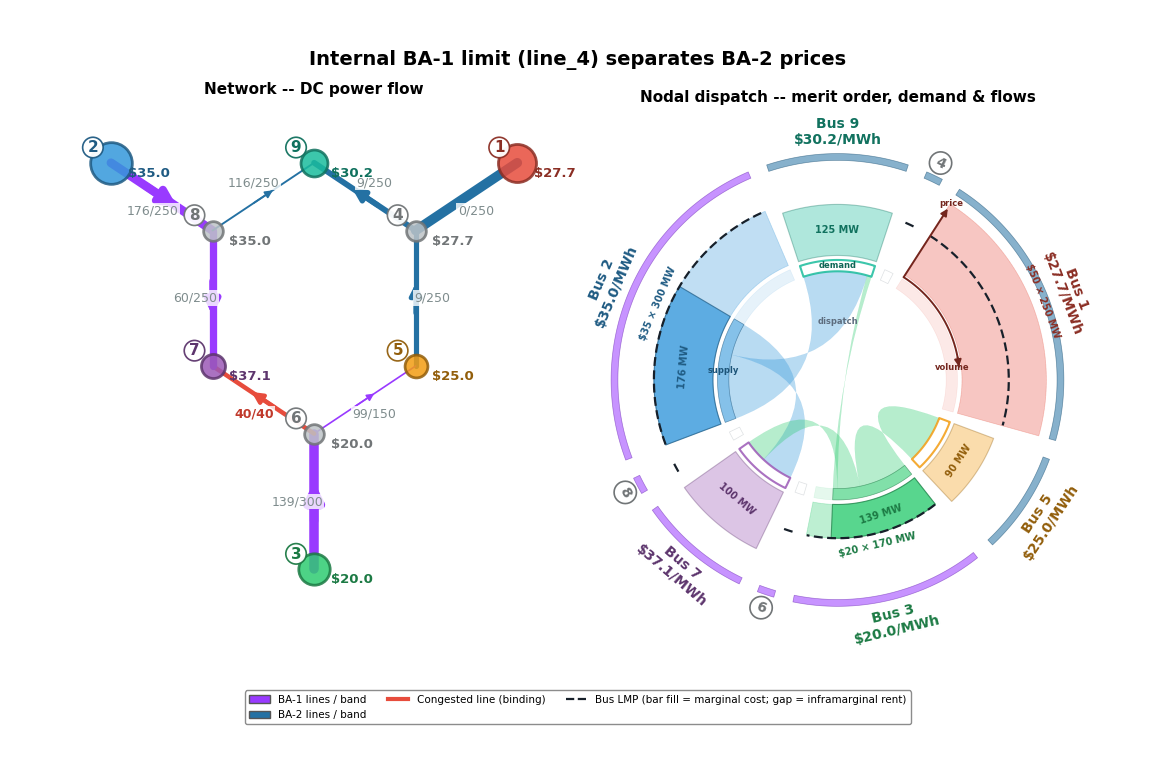

Rent on the internal BA-1 line, R = $804/h; Method 1 banks it in BA-1 (its wires host the limit), Method 2 moves tau = $1048/h to net-payer BA-2.

Compare the bottom 'Net position' row: Area net = A - N (0 => made whole); the Consumer

column is the load bill net of CRR, as a cash position (negative = cash out).

Method 1 -- each BA keeps the rent on its assigned lines:

BA-1                        BA-2                     TOTAL
                                     Consumer Generator Area net Consumer Generator Area net       
Energy settlement  (lmp x q)          -3712.6    8941.0   5228.4  -6032.5       0.0  -6032.5 -804.1
Congestion rent allocated  (A)          804.1              804.1      0.0                0.0  804.1
Net position  (Area net: 0 => whole)  -2908.5    8941.0   6032.5  -6032.5       0.0  -6032.5    0.0

Method 2 -- rebate cross-border separation tau to the net-payer BA:

BA-1                        BA-2                     TOTAL
                                     Consumer Generator Area net Consumer Generator Area net       
Energy settlement  (lmp x q)          -3712.6    8941.0   5228.4  -6032.5       0.0  -6032.5 -804.1
Congestion rent allocated  (A)         -244.3             -244.3   1048.4             1048.4  804.1
Net position  (Area net: 0 => whole)  -3956.9    8941.0   4984.1  -4984.1       0.0  -4984.1    0.0

In [15]:
# The scenario -- composite figure + homework-style congestion-revenue tables.
net = build_network(SCN_B); pt = compute_ptdf(net, slack_bus='1')
uni = make_engine('UNIFIED', buses=pt.buses); res = solve_engine_dispatch(pt, uni)
example_figure(net, pt, uni, res,
               suptitle='Internal BA-1 limit (line_4) separates BA-2 prices')
plt.show()
rtbl1, rtbl2, summ = revenue_table(res, pt, LOADS_ALL)
print(f"Rent on the internal BA-1 line, R = ${summ['R']:.0f}/h; Method 1 banks it "
      f"in BA-1 (its wires host the limit), Method 2 moves tau = ${summ['tau']:.0f}/h to "
      f"net-payer {summ['hedged_ba']}.")
print("Compare the bottom 'Net position' row: Area net = A - N (0 => made whole); the Consumer")
print("column is the load bill net of CRR, as a cash position (negative = cash out).")
print("Method 1 -- each BA keeps the rent on its assigned lines:")
display(rtbl1)
print("Method 2 -- rebate cross-border separation tau to the net-payer BA:")
display(rtbl2)

### Unified vs independent operation — the two-engine counterfactual

The cross-border separation exists only because a **single co-optimised clearing**
prices every bus against *all* constraints at once. The counterfactual is
**independent operation**: each BA runs as its own *independent engine* on the
same full 9-bus network — serving its own load from its own generators and
enforcing **only the lines assigned to it** (`LINE_BA`: its internal lines plus
its assigned tie), with every other line left unconstrained (a nodal DC-OPF per
BA, not a copperplate). No interchange is scheduled.

Two things surface:

1. On the **base network** each BA clears at its own price.
2. On the **scenario network**, BA-1's internal `line_4` limit splits prices
   *within* BA-1 and, through the shift factors, moves BA-2's prices too. Under
   the **unified clearing** the same constraint is co-optimised against the border,
   and the resulting cross-border price separation is the congestion rent that then
   has to be allocated.

In [16]:
# Independent operation: each BA as its OWN independent engine on the full network
# -- own gens serve own load, enforcing ONLY the lines assigned to it (rest
# relaxed), no interchange. A nodal DC-OPF per BA; infeasibility is a finding.
def independent_clear(rat, shed_price=None):
    # Each AREA as its own engine on the full network (a non-market area too, if
    # one exists). shed_price: pass SHED_PRICE so an undersupplied area sheds at
    # the penalty instead of failing -- the Section-4 ledgers do this; here it is
    # left off so genuine infeasibility stays visible as a finding.
    n = build_network(rat); pt = compute_ptdf(n, slack_bus='1')
    out = {}
    for area, buses in AREAS.items():
        act = [l for l in pt.lines if LINE_BA.get(l) == area]
        try:
            out[area] = solve_engine_dispatch(pt, make_engine(area, buses, activated=act),
                                              shed_price=shed_price)
        except (RuntimeError, ValueError):
            out[area] = None    # ValueError: an area with no generators at all
    return pt, out

# (a) Base network -- both BAs self-serve; the price gap is what motivates trade.
_, base = independent_clear({})
print('independent prices on the BASE network:',
      {ba: (f"${base[ba].energy_price:.0f}" if base[ba] else 'INFEASIBLE') for ba in BA_DEFS})

# (b) Scenario network -- the internal BA-1 limit as the counterfactual stress.
ptB, indep = independent_clear(SCN_B)
resU = solve_engine_dispatch(ptB, make_engine('UNIFIED', buses=ptB.buses))
cmp = pd.DataFrame({b: {
    'BA': ba_of(b),
    'independent LMP': (round(indep[ba_of(b)].lmp[b], 1) if indep[ba_of(b)] else float('nan')),
    'unified LMP (scenario)': round(resU.lmp[b], 1),
} for b in ptB.buses}).T
display(cmp)
for ba in BA_DEFS:
    if indep[ba] is None:
        print(f'{ba} is INFEASIBLE on its own: with the line_4 limit and only its own '
              f'generation it cannot serve its load -- it depends on imports across the '
              f'border. That dependence is what the unified clearing prices, and what the '
              f'congestion-revenue allocation then divides.')
    else:
        gap = max(indep[ba].lmp[b] for b in BA_DEFS[ba]) - min(indep[ba].lmp[b] for b in BA_DEFS[ba])
        print(f'{ba} independent: clears feasibly, internal price spread ${gap:.1f}/MWh.')

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


independent prices on the BASE network:

{'BA-1': '$20', 'BA-2': '$50'}

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


,BA,independent LMP,unified LMP (scenario)
1,BA-2,50.0,27.7
2,BA-1,35.0,35.0
3,BA-1,20.0,20.0
4,BA-2,50.0,27.7
5,BA-2,50.0,25.0
6,BA-1,20.0,20.0
7,BA-1,37.1,37.1
8,BA-1,35.0,35.0
9,BA-2,50.0,30.2


BA-1 independent: clears feasibly, internal price spread $17.1/MWh.

BA-2 independent: clears feasibly, internal price spread $0.0/MWh.

### The two-BA dispatch, per BA (other BA greyed)

The independent two-BA dispatch drawn as a combined network + nodal-merit chart. The other BA's nodes greyed out. Because each BA
clears only its own footprint, its chart shows only its own generation, load, and
within-BA chords. 

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


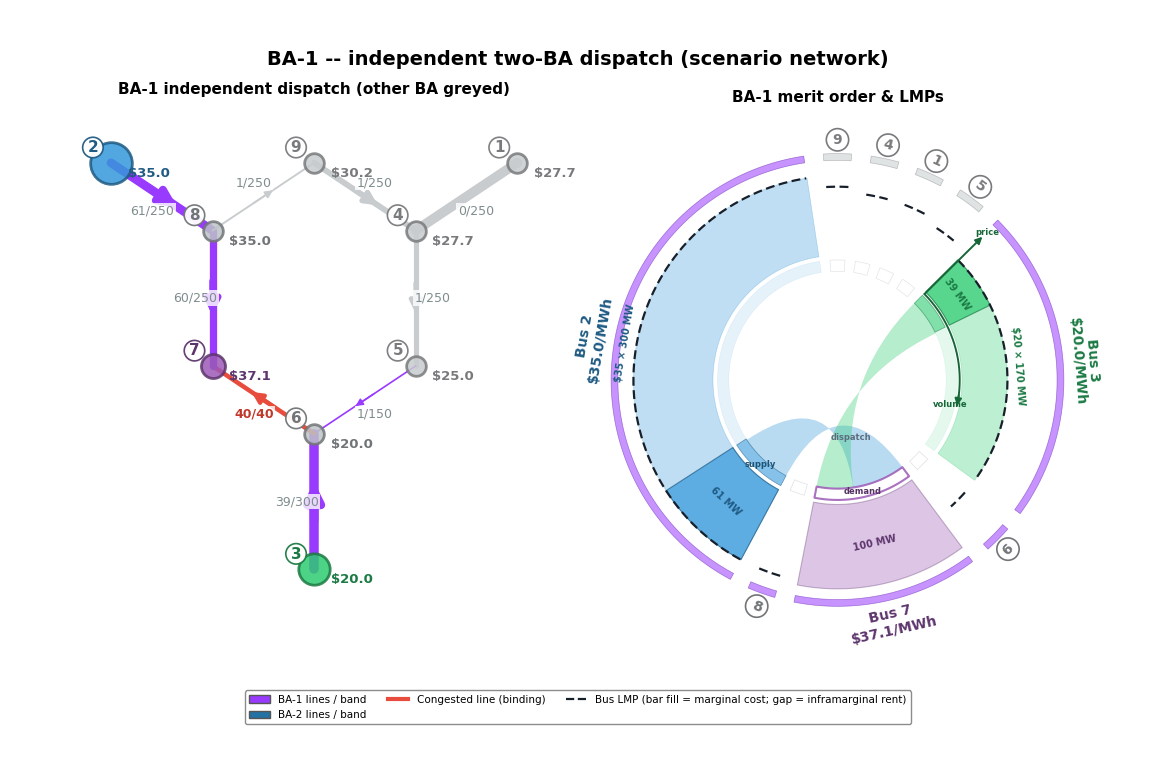

BA-1: energy $28/MWh; own-bus LMPs {'2': np.float64(35.0), '8': np.float64(35.0), '7': np.float64(37.1), '6': np.float64(20.0), '3': np.float64(20.0)}

BA-1 -- settlement by node (independent clearing):

,LMP ($/MWh),gen (MW),paid to gen ($/h),load (MW),paid by load ($/h)
bus,,,,,
2,35.0,60.6,2119.8,0.0,0.0
8,35.0,0.0,0.0,0.0,0.0
7,37.13,0.0,0.0,100.0,3712.6
6,20.0,0.0,0.0,0.0,0.0
3,20.0,39.4,788.7,0.0,0.0
SUBTOTAL,,100.0,2908.5,100.0,3712.6


BA-1 -- marginal value of its assigned lines (shadow price x flow):

,from,to,flow (MW),rating (MW),binding,|mu| ($/MWh = value of +1 MW),rent |mu| x flow ($/h)
line,,,,,,,
line_2,5,6,0.6,150.0,False,0.0,0.0
line_3,3,6,39.4,300.0,False,0.0,0.0
line_4,6,7,40.0,40.0,True,20.1,804.1
line_5,7,8,-60.0,250.0,False,0.0,0.0
line_6,8,2,-60.6,250.0,False,0.0,0.0
TOTAL,,,,,,,804.1


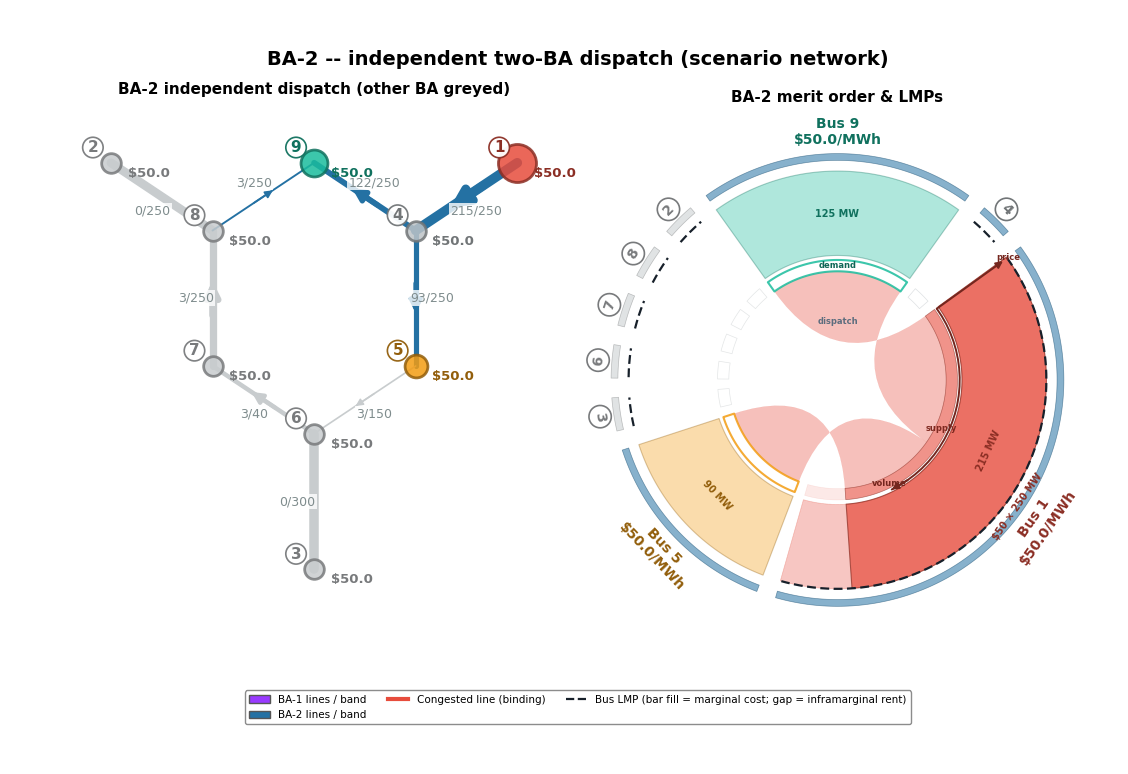

BA-2: energy $50/MWh; own-bus LMPs {'1': np.float64(50.0), '9': np.float64(50.0), '4': np.float64(50.0), '5': np.float64(50.0)}

BA-2 -- settlement by node (independent clearing):

,LMP ($/MWh),gen (MW),paid to gen ($/h),load (MW),paid by load ($/h)
bus,,,,,
1,50.0,215.0,10750.0,0.0,0.0
9,50.0,0.0,0.0,125.0,6250.0
4,50.0,0.0,0.0,0.0,0.0
5,50.0,0.0,0.0,90.0,4500.0
SUBTOTAL,,215.0,10750.0,215.0,10750.0


BA-2 -- marginal value of its assigned lines (shadow price x flow):

,from,to,flow (MW),rating (MW),binding,|mu| ($/MWh = value of +1 MW),rent |mu| x flow ($/h)
line,,,,,,,
line_0,1,4,215.0,250.0,False,0.0,0.0
line_1,4,5,93.4,250.0,False,0.0,0.0
line_7,8,9,3.4,250.0,False,0.0,0.0
line_8,9,4,-121.6,250.0,False,0.0,0.0
TOTAL,,,,,,,0.0


In [17]:
# Per-BA composite of the INDEPENDENT two-BA dispatch (scenario network),
# with the other BA's nodes greyed out. Each BA clears only its own footprint,
# so its chart carries only its own generation, load, and within-BA chords.
netB = build_network(SCN_B); ptB = compute_ptdf(netB, slack_bus='1')
for ba in BA_DEFS:
    act = [l for l in ptB.lines if LINE_BA.get(l) == ba]
    eng = make_engine(ba, BA_DEFS[ba], activated=act)
    r = solve_engine_dispatch(ptB, eng)
    other = [b for b in ptB.buses if ba_of(b) != ba]
    example_figure(netB, ptB, eng, r, dim_buses=other,
                   title_left=f'{ba} independent dispatch (other BA greyed)',
                   title_right=f'{ba} merit order & LMPs',
                   suptitle=f'{ba} -- independent two-BA dispatch (scenario network)')
    plt.show()
    print(f"{ba}: energy ${r.energy_price:.0f}/MWh; own-bus LMPs "
          f"{ {b: round(r.lmp[b], 1) for b in BA_DEFS[ba]} }")
    # Bus-level and constraint-level accounting for this BA's independent clearing
    # (the same tables as the unified clearing in Section 2, restricted to the BA).
    print(f'{ba} -- settlement by node (independent clearing):')
    display(settlement_by_bus(r, BA_DEFS[ba], LOADS_ALL))
    print(f'{ba} -- marginal value of its assigned lines (shadow price x flow):')
    display(capacity_value_by_line(r, ptB, act))

### Autarky vs unified -- the gains from trade and who captures them

Each BA's **consumer** and **generator** position under
**autarky** (independent operation -- each BA serves its own load on its own internal
limits) versus the **unified** clearing, with the congestion rent rebated to consumers
as congestion-revenue rights (CRR). 

Conventions: consumer payments are negative (cash out), generator revenue positive (cash
in); a BA's generator **position** is producer surplus (revenue minus production cost),
and its **final** consumer position is the load bill net of the CRR rebate. **Autarky also
rebates each BA's own internal congestion rent to its own consumers** -- the same CRR
treatment as the unified case -- so the comparison is like-for-like and the change versus
autarky isolates the gains from trade plus any cross-border reallocation, which drives the
Pareto check.

*Note on this fleet:* with one unit per bus each generator sets its own bus price, so
producer surplus is ~0 everywhere and the entire price wedge is congestion rent -- all
the distributional action sits on the consumer / CRR side. That degeneracy lifts once the
fleet becomes a real supply mix (a baseload block plus a sloped mid-merit/peaking ramp),
at which point the generator columns carry genuine inframarginal rent and the same ledger
keeps working unchanged. (This is a planned future enhancement.)

In [18]:
# Autarky (independent) vs unified, homework-style -- one table per allocation method.
netB = build_network(SCN_B); ptB = compute_ptdf(netB, slack_bus='1')
resU = solve_engine_dispatch(ptB, make_engine('UNIFIED', buses=ptB.buses))
_, indepB = independent_clear(SCN_B)        # each BA on its own internal limits
alloc, summ, _, _ = allocate_congestion_rent(resU, ptB, LOADS_ALL)
COST = {s['bus']: s['cost'] for s in GEN_FLEET.values()}   # bus -> marginal cost

def _agg(result, area):
    """(served-load payment, generator revenue, production cost) for an AREA
    at `result` prices -- shed load pays nothing."""
    bs = AREAS[area]
    L  = sum(result.lmp[b] * (LOADS_ALL.get(b, 0.0) - result.shed_by_bus.get(b, 0.0)) for b in bs)
    R  = sum(result.lmp[b] * result.gen_by_bus.get(b, 0.0) for b in bs)
    PC = sum(COST.get(b, 0.0) * result.gen_by_bus.get(b, 0.0) for b in bs)
    return L, R, PC

ROWS = ['Autarky: payment / revenue', 'Autarky: production cost',
        'Autarky: own congestion rent (CRR)', 'Autarky: position',
        'Unified: payment / revenue', 'Unified: production cost',
        'Congestion rent (CRR)', 'Final position', 'Delta vs autarky',
        'Pareto (Delta >= 0)']

def autarky_vs_unified(method):
    col = 'method1' if method == 1 else 'method2'
    data = {}
    for ba in AREAS:                                 # + a Non-market column when present
        La, Ra, PCa = _agg(indepB[ba], ba)          # autarky (independent)
        Lu, Ru, PCu = _agg(resU, ba)                # unified
        A = float(alloc.loc[ba, col]) if ba in alloc.index else 0.0   # CRR (BAs only)
        Ra_int = La - Ra                             # autarky: BA's OWN internal congestion rent
        PSa, PSu = Ra - PCa, Ru - PCu                # producer surplus
        cons_aut = -La + Ra_int                      # autarky consumer position (net of own CRR)
        cons_fin = -Lu + A                           # unified consumer final (net of CRR)
        cons_d = cons_fin - cons_aut                 # consumer change vs autarky
        gen_d  = PSu - PSa                           # generator (surplus) change vs autarky
        data[(ba, 'Consumer')] = {
            'Autarky: payment / revenue': -La, 'Autarky: production cost': '',
            'Autarky: own congestion rent (CRR)': Ra_int, 'Autarky: position': cons_aut,
            'Unified: payment / revenue': -Lu, 'Unified: production cost': '',
            'Congestion rent (CRR)': A, 'Final position': cons_fin,
            'Delta vs autarky': cons_d,
            'Pareto (Delta >= 0)': 'yes' if cons_d >= -1e-6 else 'no'}
        data[(ba, 'Generator')] = {
            'Autarky: payment / revenue': Ra, 'Autarky: production cost': -PCa,
            'Autarky: own congestion rent (CRR)': '', 'Autarky: position': PSa,
            'Unified: payment / revenue': Ru, 'Unified: production cost': -PCu,
            'Congestion rent (CRR)': '', 'Final position': PSu,
            'Delta vs autarky': gen_d,
            'Pareto (Delta >= 0)': 'yes' if gen_d >= -1e-6 else 'no'}
    df = pd.DataFrame(data).reindex(ROWS)
    df.columns = pd.MultiIndex.from_tuples(df.columns)
    return df.map(lambda v: round(v, 1) if isinstance(v, (int, float)) and not isinstance(v, bool) else v)

pc_aut = sum(_agg(indepB[ba], ba)[2] for ba in AREAS)
pc_uni = sum(_agg(resU, ba)[2] for ba in AREAS)
print(f"System production cost: autarky ${pc_aut:,.0f}/h  ->  unified ${pc_uni:,.0f}/h  "
      f"(gains from trade ${pc_aut - pc_uni:,.0f}/h);  congestion rent R = ${summ['R']:.0f}/h.")
print("Autarky rebates each BA's own internal congestion rent to its own consumers, so "
      "Delta-vs-autarky isolates the gains from trade and the cross-border reallocation.")
print("\nMethod 1 -- each BA keeps the rent on its assigned lines:")
display(autarky_vs_unified(1))
print("Method 2 -- rebate the cross-border separation tau to the net-payer BA:")
display(autarky_vs_unified(2))

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


System production cost: autarky $13,659/h  ->  unified $8,941/h  (gains from trade $4,717/h);  congestion rent R = $804/h.

Autarky rebates each BA's own internal congestion rent to its own consumers, so Delta-vs-autarky isolates the gains from trade and the cross-border reallocation.


Method 1 -- each BA keeps the rent on its assigned lines:

BA-1               BA-2          
                                   Consumer Generator Consumer Generator
Autarky: payment / revenue          -3712.6    2908.5 -10750.0   10750.0
Autarky: production cost                      -2908.5           -10750.0
Autarky: own congestion rent (CRR)    804.1                0.0          
Autarky: position                   -2908.5       0.0 -10750.0       0.0
Unified: payment / revenue          -3712.6    8941.0  -6032.5       0.0
Unified: production cost                      -8941.0               -0.0
Congestion rent (CRR)                 804.1                0.0          
Final position                      -2908.5       0.0  -6032.5       0.0
Delta vs autarky                        0.0       0.0   4717.5       0.0
Pareto (Delta >= 0)                     yes       yes      yes       yes

Method 2 -- rebate the cross-border separation tau to the net-payer BA:

BA-1               BA-2          
                                   Consumer Generator Consumer Generator
Autarky: payment / revenue          -3712.6    2908.5 -10750.0   10750.0
Autarky: production cost                      -2908.5           -10750.0
Autarky: own congestion rent (CRR)    804.1                0.0          
Autarky: position                   -2908.5       0.0 -10750.0       0.0
Unified: payment / revenue          -3712.6    8941.0  -6032.5       0.0
Unified: production cost                      -8941.0               -0.0
Congestion rent (CRR)                -244.3             1048.4          
Final position                      -3956.9       0.0  -4984.1       0.0
Delta vs autarky                    -1048.4       0.0   5765.9       0.0
Pareto (Delta >= 0)                      no       yes      yes       yes

## 4. Optimized transfers

Transfers between balancing authority areas in the market footprint are
optimized. The market enforces a **scheduling limit** on the net interchange
between the footprints: in EDAM, a transfer is modelled as a matching
export/import pair between two balancing authorities, each BAA's **net
transfer** enters its own power balance, and the scheduling limits are
enforced beside the line limits, under the same generalized network
constraint index. In concept, the transfers are a transport layer on top of
the nodal network layer.

This section adds that transport-layer constraint to the nodal dispatch
developed above: a single limit $\bar E$ on the **net energy interchange** $E$
between BA-1 and BA-2. Its natural ceiling is the **combined rating of the
ties** that physically connect the BAs (`line_2` + `line_7`) — a limit above
that can never bind, because the tie flows already cap the interchange.




### The clearing with a transfer constraint — objective, Lagrangian, prices

**Nomenclature.** The Section-2 symbols carry over with the engine superscript
dropped — the unified clearing is the single engine, exactly as in eq. (6):

| Symbol | Definition |
|---|---|
| $\mathcal N$, $\mathcal R$, $\mathcal M_{\mathrm{act}}$ | buses ($n$), resources ($i$), and activated lines ($m$) — Section 2's sets; every line is activated here |
| $g_i,\ \bar g_i,\ c_i$ | dispatch of resource $i$ (the decision variable), its capacity, and its marginal cost |
| $d_n$ | load at bus $n$ |
| $F_m,\ \bar F_m,\ SF_{n,m}$ | flow on line $m$, its operating limit, and the shift factor of bus $n$ on it |
| $\lambda,\ \lambda_n$ | the energy price (balance dual) and the nodal LMP at bus $n$ (eq. 5) |
| $\mu_m$ | shadow price of line $m$'s activated limit |
| $R$ | congestion rent, $\sum_m\lvert\mu_m F_m\rvert$ (eq. 6) |

New in this section (the BA partition and ties are Section 3's):

| Symbol | Definition |
|---|---|
| $a$, $\mathcal N_a$ | a balancing authority and its bus set (Section 3); $\mathcal N_1$ is BA-1's |
| $\mathcal M^{\mathrm{tie}}$ | the ties — lines whose ends sit in different BAs (Section 3) |
| $\partial\mathcal N_1$ | BA-1's boundary — lines with exactly one end in $\mathcal N_1$ ($=\mathcal M^{\mathrm{tie}}$ when the BAs cover every bus) — eq. (13) |
| $E$ | **net energy interchange** out of BA-1, MW (export positive) — eq. (13) |
| $s_m$ | boundary orientation: $+1$ if line $m$'s from-bus is in $\mathcal N_1$, else $-1$ — eq. (13) |
| $\bar E$ | the **transfer (scheduling) limit** on $\lvert E\rvert$ (`TRANSFER_LIMIT` / `XFER_BIND`) |
| $\mu_T$ | shadow price of the transfer constraint — signed, \$/MWh (`res.interchange_dual`) — eq. (14) |
| $\mathbb 1\{n\in\mathcal N_1\}$ | indicator: $1$ for a BA-1 bus, $0$ otherwise — eq. (16) |
| $R_T$ | **transfer rent**, $\lvert\mu_T\,E\rvert$, \$/h — eq. (17) |
| $\sigma_a$ | (sigma) BA $a$'s **share of the transfer rent**, $\sum_a\sigma_a=1$ — set by the transfer methodology (`allocate_transfer_rent`): T1 the fixed `TRANSFER_SPLIT` shares, T2 all to the net-payer BA |
| $A^T_a$ | transfer rent **allocated** to BA $a$: $A^T_a=\sigma_a\,R_T$, \$/h — eq. (17) |

The dispatch is the Section-2 problem (eqs. (1)–(5); unified single engine,
every line activated) with **one new constraint**. Write $\mathcal N_1$ for
BA-1's bus set and define the **net interchange** out of BA-1:

$$E=\sum_{i:\,\mathrm{bus}(i)\in\mathcal N_1} g_i-\sum_{n\in\mathcal N_1} d_n
   \;=\;\sum_{m\,\in\,\partial\mathcal N_1} s_m\,F_m,
   \qquad s_m=\begin{cases}+1 & \text{line $m$'s from-bus} \in\mathcal N_1,\\ -1 & \text{otherwise.}\end{cases} \qquad (13)$$

*In words.* BA-1's net interchange is whatever its generators produce beyond
its own load (served load, $d_n-u_n$, wherever the Section-2 relaxation sheds).
$\partial\mathcal N_1$ is BA-1's **boundary** — every line with exactly one end
inside $\mathcal N_1$. Lossless DC gives the second equality for free: every
megawatt BA-1 does not consume must leave over its boundary, so the *scheduled*
interchange and the *summed physical boundary flow* are the same number — one
constraint, two readings. Here the two BAs cover every bus, so
$\partial\mathcal N_1=\mathcal M^{\mathrm{tie}}$; with a **non-market area** the
boundary also counts BA-1's lines into it, while $\mathcal M^{\mathrm{tie}}$ —
and the $\tau$ of eq. (9) built on it — stays the BA-to-BA border.

**The problem, restated with the transfer constraint.**

$$\min_{0\le g_i\le\bar g_i}\ \sum_{i\in\mathcal R} c_i\,g_i
  \quad\text{s.t.}\quad
  \sum_{i\in\mathcal R} g_i=\sum_{n\in\mathcal N} d_n\ \ [\lambda],\qquad
  -\bar F_m\le F_m\le\bar F_m\ \ [\mu_m]\ \ (m\in\mathcal M_{\mathrm{act}}),\qquad
  -\bar E\le E\le\bar E\ \ [\mu_T]. \qquad (14)$$

*In words.* The objective and the first two constraint families are exactly
Section 2's (1)–(3); the transfer constraint is one more row with its own
(signed) multiplier $\mu_T$ — in EDAM terms, an intertie scheduling limit
enforced beside the line limits under the same generalized constraint index.

**The Lagrangian with the new term.**

$$\mathcal L=\sum_{i\in\mathcal R} c_i\,g_i
  -\lambda\Big(\sum_{i\in\mathcal R} g_i-\sum_{n\in\mathcal N} d_n\Big)
  -\!\!\sum_{m\in\mathcal M_{\mathrm{act}}}\!\!\mu_m\,F_m
  \;-\;\mu_T\,E
  \;+\;\sum_{i\in\mathcal R}\overline\mu_i\,(g_i-\bar g_i)-\sum_{i\in\mathcal R}\underline\mu_i\,g_i. \qquad (15)$$

*In words.* Equation (4) plus **one term**: the transfer multiplier times the
interchange. Complementary slackness works as before — $\mu_T\neq 0$ only when
the schedule sits at $\pm\bar E$.

**Stationarity → per-BA energy prices.** For a generator $i$ at bus $n$,
$\partial E/\partial g_i=\mathbb 1\{n\in\mathcal N_1\}$, so for a marginal unit
the bound multipliers drop and the bus price becomes

$$\lambda_n=\lambda+\sum_{m\in\mathcal M_{\mathrm{act}}}SF_{n,m}\,\mu_m
   +\mathbb 1\{n\in\mathcal N_1\}\,\mu_T. \qquad (16)$$

*In words.* Every BA-1 bus carries the **same** extra term. With no line
binding, prices are *flat within each BA* and differ *between* the BAs by
$|\mu_T|$: the transfer constraint splits the single energy price $\lambda$
into two BA-level energy prices — exactly the EDAM structure, where each BAA
carries its own power-balance dual linked by the scheduled transfer. (With the
slack bus in BA-2, $\mu_T<0$ when BA-1's export cap binds: the exporter's
prices sit $|\mu_T|$ *below* the importer's.)

**Transfer rent — a second revenue stream.**

$$R_T=\big|\,\mu_T\,E\,\big|,\qquad
  \underbrace{\sum_{n\in\mathcal N}\lambda_n d_n-\sum_{n\in\mathcal N}\lambda_n g_n}_{\text{paid by load}\ -\ \text{paid to generation}}=R+R_T,\qquad
  A^T_a=\sigma_a\,R_T,\quad \sum\nolimits_a\sigma_a=1. \qquad (17)$$

*In words.* The wedge between what load pays and what generation receives now
has two pieces: the line congestion rent $R$ of eq. (6) and the **transfer
rent** $R_T$ collected on the constrained schedule — the border price gap times
the megawatts crossing it. $R_T$ is a **separate revenue stream** from congestion rent; whenever the
constraint binds it is **allocated by a configurable transfer methodology** —
the $\sigma_a$ of the `allocate_transfer_rent` block: **T1** fixed shares
(`TRANSFER_SPLIT`, default 50/50), **T2** the whole $R_T$ to the net-payer BA,
the transfer analogue of Method 2's rebate. The optimization fixes
$R_T$ itself — the constraint and its dual price the schedule — but not who
receives it: the split is a settlement rule chosen outside the dispatch (EDAM
likewise shares transfer revenue equally between the two BAAs), written here so it
can be refined. Methods 1 and 2 still apply to $R$ only, and because eq. (9)
prices $\tau$ through the **line** multipliers, the separation the schedule
creates is settled exactly once — as $R_T$ — and never re-enters the Method-2
rebate. The transfer row is identical in both ledgers.


In [19]:
# -- EDIT -- the transfer (interchange scheduling) limit ---------------------
TIE_CAP = float(sum(pt.s_nom[pt.line_idx[l]] for l in ties))   # combined tie rating: the physical envelope
TRANSFER_LIMIT = TIE_CAP    # Ebar; lower it below TIE_CAP to make the SCHEDULE bind
# -- EDIT -- allocation methodologies for the two revenue streams -------------
CONGESTION_METHODS = [1, 2]                   # Section-3 congestion rules to tabulate (one ledger each)
TRANSFER_METHODS   = [1, 2]                   # transfer rules to tabulate: 1 = fixed shares, 2 = net-payer
TRANSFER_SPLIT = {'BA-1': 0.5, 'BA-2': 0.5}   # Method T1's shares sigma_a (EDAM: equal split)
# ----------------------------------------------------------------------------
assert set(TRANSFER_SPLIT) == set(BA_DEFS) and abs(sum(TRANSFER_SPLIT.values()) - 1.0) < 1e-9, \
    'TRANSFER_SPLIT must cover both BAs and sum to 1'

T_NAMES = {1: 'T1 -- fixed shares (TRANSFER_SPLIT)',
           2: 'T2 -- all to the net-payer BA'}

def allocate_transfer_rent(res, loads, t_method):
    """The sigma_a of eq. (17), by transfer methodology -- edit or extend this
    block exactly like the Section-3 congestion methodology functions:
    T1 -- fixed shares TRANSFER_SPLIT (default 50/50, EDAM's equal sharing of
          transfer revenue between the two BAAs);
    T2 -- the whole R_T to the NET-PAYER BA (the side whose load over-paid
          across the constrained border) -- the transfer analogue of congestion
          Method 2's rebate.
    Returns {ba: dollars of R_T allocated}."""
    RT = transfer_rent(res)
    if t_method == 1:
        return {ba: TRANSFER_SPLIT[ba] * RT for ba in BA_DEFS}
    if t_method == 2:
        s = ba_settlement(res, loads)
        payer = max(BA_DEFS, key=lambda ba: s[ba]['net_into_pool'])
        return {ba: (RT if ba == payer else 0.0) for ba in BA_DEFS}
    raise ValueError(f'unknown transfer methodology {t_method!r}')

def solve_with_transfer(ratings, ebar):
    """Unified clearing with the net-interchange constraint |E| <= ebar (eq. 14)
    and the Section-2 load-shed relaxation active (slack in every demo here)."""
    n = build_network(ratings); p = compute_ptdf(n, slack_bus='1')
    e = make_engine('UNIFIED', buses=p.buses)
    r = solve_engine_dispatch(p, e, interchange=(BA_DEFS['BA-1'], ebar),
                              shed_price=SHED_PRICE)
    return n, p, e, r

def transfer_rent(res):
    """R_T = |mu_T * E| -- zero unless the transfer constraint binds (eq. 17)."""
    return abs((res.interchange_dual or 0.0) * (res.interchange_mw or 0.0))

def transfer_ledger(res, p, loads, method, t_method, indep):
    """Autarky vs the transfer-constrained clearing, homework-style -- the same
    per-BA Consumer/Generator layout, sign conventions (cash out negative), and
    Pareto check as the Section-3 autarky-vs-unified ledger, with the two
    revenue streams shown COLLECTED separately from ALLOCATED:
    - congestion rent is collected on binding lines (per BA = the lines it is
      assigned, eq. 8; TOTAL = R including any unassigned-line rent) and
      allocated by Section-3 Method `method` (eqs. 10/11);
    - transfer rent is collected at the border (TOTAL column only -- it belongs
      to the schedule, not to either BA's wires) and allocated by transfer
      methodology `t_method` (the `allocate_transfer_rent` block: T1 fixed
      shares, T2 all to the net-payer BA; eq. 17).
    indep: autarky results from independent_clear(ratings, shed_price=SHED_PRICE)
    on the SAME ratings (each AREA self-serves on its own lines; own internal
    rent rebated to own consumers, like-for-like with the CRR treatment here;
    an undersupplied area sheds at the penalty rather than failing). Areas =
    the BAs plus a Non-market column when buses sit outside both -- it settles
    at LMP, is allocated nothing. The TOTAL column tells the welfare story:
    positions sum to -(production cost), so the 'Delta vs autarky' TOTAL is
    exactly the production-cost saving."""
    alloc, summ, lr, sep = allocate_congestion_rent(res, p, loads)
    col = 'method1' if method == 1 else 'method2'
    RT = transfer_rent(res)
    AT_map = allocate_transfer_rent(res, loads, t_method)
    data = {}
    for ba in AREAS:
        assert indep[ba] is not None, (f'{ba} has no autarky baseline -- pass '
                                       'shed_price=SHED_PRICE to independent_clear '
                                       '(or the area has no generators at all)')
        La, Ra, PCa = _agg(indep[ba], ba)            # autarky, at its own prices
        Lc, Rc, PCc = _agg(res, ba)                  # the transfer-constrained clearing
        own_aut = La - Ra                            # autarky internal rent -> own consumers
        A = float(alloc.loc[ba, col]) if ba in alloc.index else 0.0
        AT = AT_map.get(ba, 0.0)
        cons_aut, gen_aut = -La + own_aut, Ra - PCa
        cons_fin, gen_fin = -Lc + A + AT, Rc - PCc
        data[(ba, 'Consumer')] = {
            'Autarky: payment / revenue': -La, 'Autarky: production cost': '',
            'Autarky: own congestion rent (CRR)': own_aut, 'Autarky: position': cons_aut,
            'Constrained: payment / revenue': -Lc, 'Constrained: production cost': '',
            'Congestion rent collected (assigned lines)': summ['R_own'].get(ba, 0.0),
            'Congestion rent allocated (CRR)': A,
            'Transfer rent collected (border)': '',
            'Transfer rent allocated (CRR)': AT,
            'Final position': cons_fin,
            'Delta vs autarky': cons_fin - cons_aut,
            'Pareto (Delta >= 0)': 'yes' if cons_fin - cons_aut >= -1e-6 else 'no'}
        data[(ba, 'Generator')] = {
            'Autarky: payment / revenue': Ra, 'Autarky: production cost': -PCa,
            'Autarky: own congestion rent (CRR)': '', 'Autarky: position': gen_aut,
            'Constrained: payment / revenue': Rc, 'Constrained: production cost': -PCc,
            'Congestion rent collected (assigned lines)': '',
            'Congestion rent allocated (CRR)': '',
            'Transfer rent collected (border)': '',
            'Transfer rent allocated (CRR)': '',
            'Final position': gen_fin,
            'Delta vs autarky': gen_fin - gen_aut,
            'Pareto (Delta >= 0)': 'yes' if gen_fin - gen_aut >= -1e-6 else 'no'}
    df = pd.DataFrame(data)
    df.columns = pd.MultiIndex.from_tuples(df.columns)
    tot = df.map(lambda v: v if isinstance(v, (int, float)) else 0.0).sum(axis=1)
    tot['Congestion rent collected (assigned lines)'] = summ['R']   # includes unassigned-line rent
    tot['Transfer rent collected (border)'] = RT
    tot = tot.astype(object); tot['Pareto (Delta >= 0)'] = ''
    df[('TOTAL', '')] = tot
    return df.map(lambda v: round(v, 1) if isinstance(v, (int, float)) else v)

def draw_net_dispatch(ax, res, ebar, engine):
    """The Transfers inset: each BA collapses to ONE bubble drawn at the SAME
    scale as the network panel's bus bubbles (scatter s = max(3 x MW, 200),
    MW = generation capacity + load -- the BA's total addressable market),
    labelled with its net surplus. The connecting line carries the
    interchange as a flow/limit label exactly like a network line's
    flow/rating label; its width is ebar relative to the combined tie rating
    TIE_CAP (thin = tight tie); when the constraint binds the line turns red,
    the label sits at its limit (e.g. 120/120), and |mu_T| prints below it as
    a price label."""
    from math import pi
    sup, dem = to_supply_demand(engine, res)
    tam, surplus = {}, {}
    for ba, buses in BA_DEFS.items():
        bs = [str(b) for b in buses]
        tam[ba] = (sum(g.get('capacity', g['volume'])
                       for b in bs for g in sup.get(b, []))
                   + sum(dem.get(b, 0.0) for b in bs))
        surplus[ba] = (sum(res.gen_by_bus.get(b, 0.0) for b in bs)
                       - sum(res.load_by_bus.get(b, 0.0) - res.shed_by_bus.get(b, 0.0)
                             for b in bs))
    size = {ba: max(tam[ba] * 3.0, 200.0) for ba in BA_DEFS}   # network rule
    # Bubble radii in axes fractions (scatter s is in points^2): anchor the
    # arrow at the bubble edges, and shrink uniformly if a bigger fleet would
    # ever push a bubble outside the inset frame.
    fig = ax.figure
    pos = ax.get_position()
    w_pts = pos.width * fig.get_size_inches()[0] * 72.0
    h_pts = pos.height * fig.get_size_inches()[1] * 72.0
    r_pts = {ba: (size[ba] / pi) ** 0.5 for ba in BA_DEFS}
    shrink = min(1.0, 0.30 * h_pts / max(r_pts.values()))
    size = {ba: size[ba] * shrink ** 2 for ba in BA_DEFS}
    r_pts = {ba: r * shrink for ba, r in r_pts.items()}

    centers = {'BA-1': (0.22, 0.45), 'BA-2': (0.78, 0.45)}
    binding = abs(res.interchange_dual or 0.0) > 1e-3
    lw = 0.8 + 4.2 * min(1.0, ebar / TIE_CAP)       # thin line = tight tie
    color = '#E74C3C' if binding else '#7F8C8D'
    e = float(res.interchange_mw or 0.0)
    rx = {ba: r_pts[ba] / w_pts for ba in BA_DEFS}
    x0 = centers['BA-1'][0] + rx['BA-1']
    x1 = centers['BA-2'][0] - rx['BA-2']
    a, b = ((x0, x1) if e >= 0 else (x1, x0))       # arrow follows the flow
    ax.annotate('', xy=(b, 0.45), xytext=(a, 0.45),
                arrowprops=dict(arrowstyle='-|>', color=color, lw=lw,
                                mutation_scale=8 + lw, shrinkA=0, shrinkB=0))
    for ba, (cx, cy) in centers.items():
        ax.scatter(cx, cy, s=size[ba], c=BA_COLORS[ba], ec='#333', lw=2,
                   alpha=0.85, zorder=3)
        ax.text(cx, cy, f'{ba}\n{surplus[ba]:+,.0f}', ha='center', va='center',
                fontsize=7, color='white', fontweight='bold', zorder=4)
    # Interchange label, styled like the network panel's flow/rating labels.
    ax.text(0.5, 0.70, f'{abs(e):.0f}/{ebar:.0f}',
            fontsize=9, color='#C0392B' if binding else '#7F8C8D',
            fontweight='bold' if binding else 'normal',
            ha='center', va='center',
            bbox=dict(fc='white', ec='none', alpha=0.8, pad=1))
    if binding:   # the transfer shadow price, styled like the bus price labels
        ax.text(0.5, 0.16, f'${abs(res.interchange_dual):.2f}',
                fontsize=9.5, color='#C0392B', fontweight='bold',
                ha='center', va='center')
    ax.set_title('Transfers', fontsize=11, fontweight='bold', pad=4)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.axis('off')

def transfer_figure(n, p, e, r, ebar, suptitle=None):
    """example_figure plus ONE Transfers inset, in the lower left of the
    network panel, at the network panel's own bubble scale."""
    fig = example_figure(n, p, e, r, suptitle=suptitle)
    draw_net_dispatch(fig.add_axes((0.005, 0.02, 0.19, 0.235)), r, ebar, e)
    return fig

print(f'transfer model loaded: TIE_CAP = {TIE_CAP:.0f} MW (combined tie rating: '
      + ' + '.join(f'{l} {pt.s_nom[pt.line_idx[l]]:.0f}' for l in ties)
      + f');  TRANSFER_LIMIT = {TRANSFER_LIMIT:.0f} MW')
print('allocation knobs: CONGESTION_METHODS = ' + str(CONGESTION_METHODS)
      + ',  TRANSFER_METHODS = ' + str(TRANSFER_METHODS) + ' (T1 shares: '
      + ' / '.join(f'{ba} {TRANSFER_SPLIT[ba]:.0%}' for ba in BA_DEFS) + ')')


transfer model loaded: TIE_CAP = 400 MW (combined tie rating: line_2 150 + line_7 250);  TRANSFER_LIMIT = 400 MW

allocation knobs: CONGESTION_METHODS = [1, 2],  TRANSFER_METHODS = [1, 2] (T1 shares: BA-1 50% / BA-2 50%)

*Reading the figures below.* Each figure gains a small **Transfers** inset
in the lower left of the network panel, drawn to the network diagram's own
visual conventions: each BA collapses to one bubble **sized like the network's
bus bubbles** (generation capacity plus load — the BA's total addressable
market) and labelled with its **net surplus**; the connecting line carries the
interchange as a `flow/limit` label, exactly like a line's `flow/rating`, and
its **width is the transfer limit** $\bar E$ relative to the combined tie
rating — a thin line is a tight tie. When the constraint binds the line turns
**red**, the label sits at its limit (`120/120`), and the transfer shadow
price $|\mu_T|$ appears below it as a price label.

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


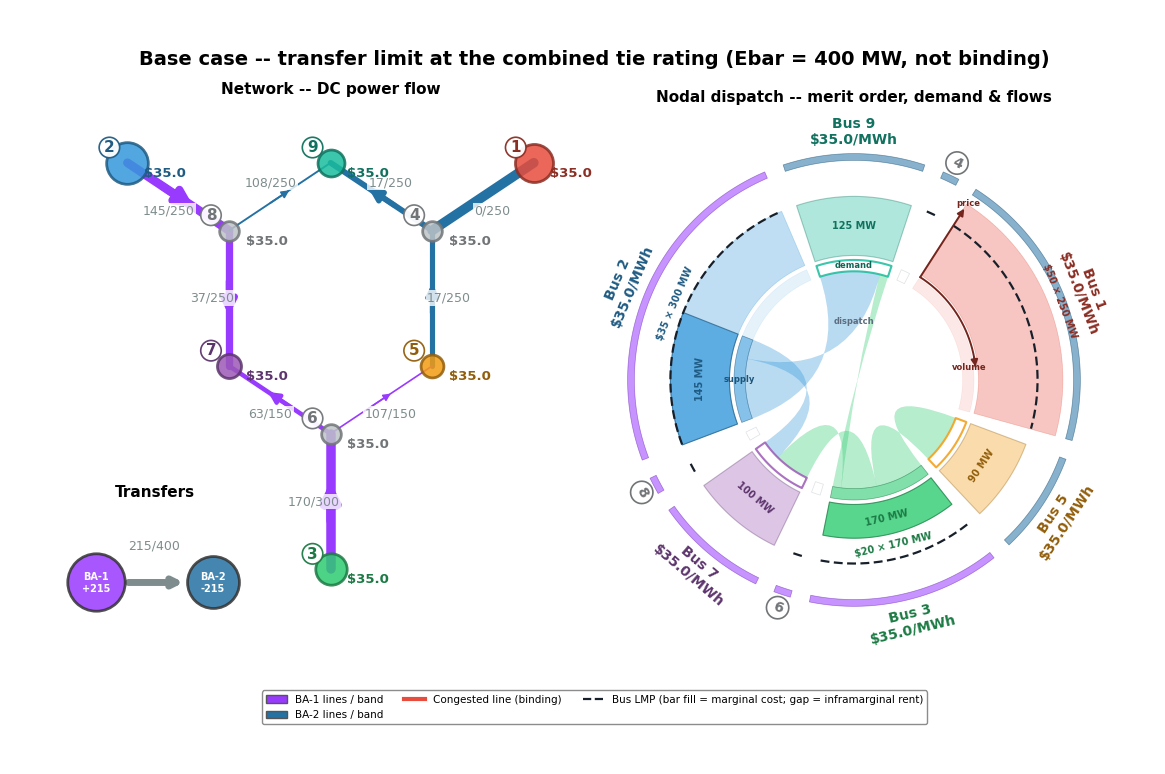

interchange E = 215.0 MW of Ebar = 400 MW  ->  mu_T = 0.00  (not binding)

LMP by bus:

{'1': np.float64(35.0), '2': np.float64(35.0), '3': np.float64(35.0), '4': np.float64(35.0), '5': np.float64(35.0), '6': np.float64(35.0), '7': np.float64(35.0), '8': np.float64(35.0), '9': np.float64(35.0)}

Identical to the unconstrained base clearing: at the physical envelope the transfer constraint adds nothing, and E settles at the 215 MW the network chooses.

In [20]:
# Sample dispatch -- the same base example, transfer limit at the physical envelope.
# At Ebar = TIE_CAP the schedule may use the full combined tie rating, so the
# constraint cannot cut below what the wires already allow -- it is inert.
netT, ptT, engT, resT = solve_with_transfer({}, TRANSFER_LIMIT)
fig = transfer_figure(netT, ptT, engT, resT, TRANSFER_LIMIT,
                      suptitle=f'Base case -- transfer limit at the combined tie rating '
                               f'(Ebar = {TRANSFER_LIMIT:.0f} MW, not binding)')
plt.show()
print(f'interchange E = {resT.interchange_mw:.1f} MW of Ebar = {TRANSFER_LIMIT:.0f} MW'
      f'  ->  mu_T = {resT.interchange_dual:.2f}  (not binding)')
print('LMP by bus:', {bb: round(resT.lmp[bb], 1) for bb in ptT.buses})
print(f'Identical to the unconstrained base clearing: at the physical envelope the '
      f'transfer constraint adds nothing, and E settles at the '
      f'{resT.interchange_mw:.0f} MW the network chooses.')


### The transfer constraint binding

Lower $\bar E$ below the interchange the network wants and the **schedule**
becomes the binding constraint: no wire is at its limit, yet the two BAs'
prices separate by exactly $|\mu_T|$, flat within each footprint (eq. 16). The
wedge that opens between what load pays and what generation receives is the
transfer rent $R_T=|\mu_T E|$ of eq. (17) — a revenue stream the *border itself*
collects, distinct from any line's congestion rent, allocated by the
configured transfer methodology (`TRANSFER_METHODS` — T1 fixed `TRANSFER_SPLIT`
shares, T2 all to the net-payer BA). The ledgers below follow the
autarky-vs-unified format: each BA's consumers and generators side by side,
the **autarky counterfactual on the same ratings**, both revenue streams with
**collected** kept separate from **allocated**, and a **Pareto check** on who
the constrained trade leaves better off. Edit `XFER_BIND` to tighten or relax
the border, and `CONGESTION_METHODS` / `TRANSFER_METHODS` (+ `TRANSFER_SPLIT`,
T1's shares) to change how each stream is allocated.


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


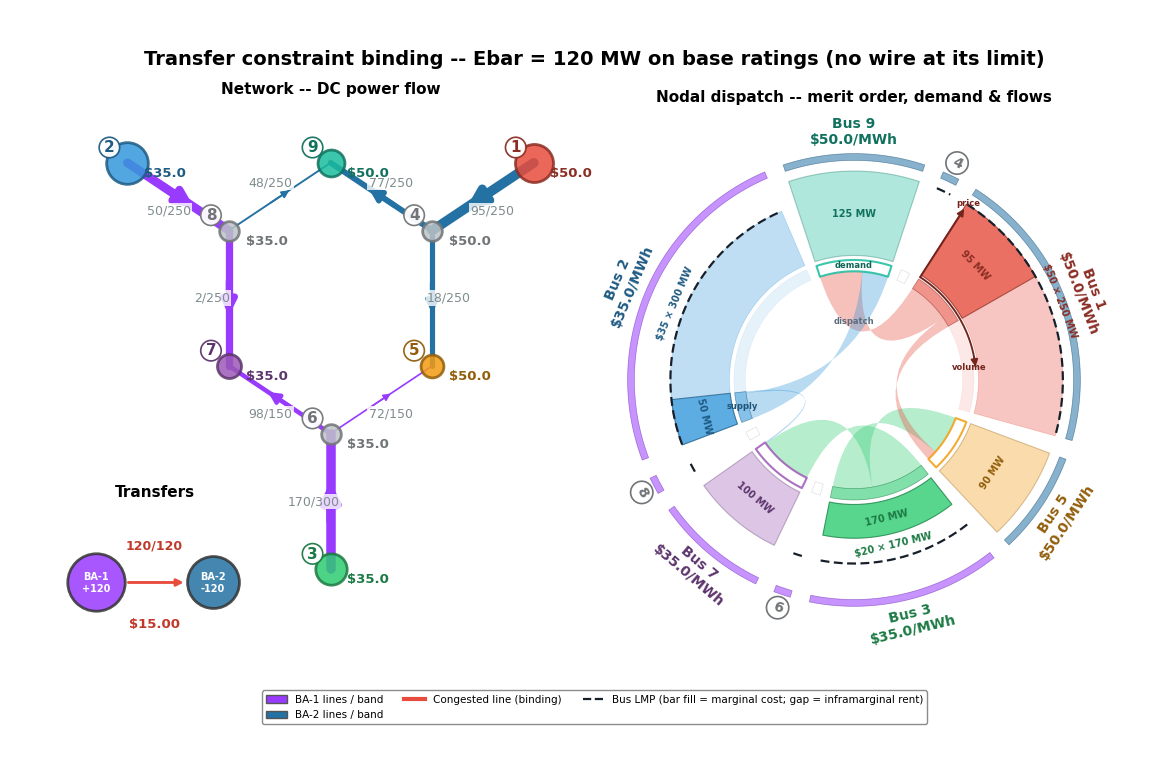

E = 120.0 MW at Ebar = 120  ->  mu_T = -15.00 $/MWh

  BA-1 LMPs:

{'2': np.float64(35.0), '8': np.float64(35.0), '7': np.float64(35.0), '6': np.float64(35.0), '3': np.float64(35.0)}

  BA-2 LMPs:

{'1': np.float64(50.0), '9': np.float64(50.0), '4': np.float64(50.0), '5': np.float64(50.0)}

...

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines



Ledger -- autarky vs constrained trade; transfer rent by T1 -- fixed shares (TRANSFER_SPLIT)  (congestion Method 1: tau = 0, methods coincide):

BA-1               BA-2              TOTAL
                                           Consumer Generator Consumer Generator         
Autarky: payment / revenue                  -2000.0    2000.0 -10750.0   10750.0      0.0
Autarky: production cost                              -2000.0           -10750.0 -12750.0
Autarky: own congestion rent (CRR)              0.0                0.0                0.0
Autarky: position                           -2000.0       0.0 -10750.0       0.0 -12750.0
Constrained: payment / revenue              -3500.0    7700.0 -10750.0    4750.0  -1800.0
Constrained: production cost                          -5150.0            -4750.0  -9900.0
Congestion rent collected (assigned lines)      0.0                0.0                0.0
Congestion rent allocated (CRR)                 0.0                0.0                0.0
Transfer rent collected (border)                                                   1800.0
Transfer rent allocated (CRR)                 900.0              900.0             1800.0
Final position                              -2600.0    2550.0  -9850.0       0.0  -9900.0
Delta vs autarky                             -600.0    2550.0    900.0       0.0   2850.0
Pareto (Delta >= 0)                              no       yes      yes       yes


Ledger -- autarky vs constrained trade; transfer rent by T2 -- all to the net-payer BA  (congestion Method 1: tau = 0, methods coincide):

BA-1               BA-2              TOTAL
                                           Consumer Generator Consumer Generator         
Autarky: payment / revenue                  -2000.0    2000.0 -10750.0   10750.0      0.0
Autarky: production cost                              -2000.0           -10750.0 -12750.0
Autarky: own congestion rent (CRR)              0.0                0.0                0.0
Autarky: position                           -2000.0       0.0 -10750.0       0.0 -12750.0
Constrained: payment / revenue              -3500.0    7700.0 -10750.0    4750.0  -1800.0
Constrained: production cost                          -5150.0            -4750.0  -9900.0
Congestion rent collected (assigned lines)      0.0                0.0                0.0
Congestion rent allocated (CRR)                 0.0                0.0                0.0
Transfer rent collected (border)                                                   1800.0
Transfer rent allocated (CRR)                   0.0             1800.0             1800.0
Final position                              -3500.0    2550.0  -8950.0       0.0  -9900.0
Delta vs autarky                            -1500.0    2550.0   1800.0       0.0   2850.0
Pareto (Delta >= 0)                              no       yes      yes       yes

In [21]:
# -- EDIT -- bind the border: schedule less than the network wants to move ------
XFER_BIND = 120.0          # Ebar below the ~215 MW unconstrained interchange
# ------------------------------------------------------------------------------
netX, ptX, engX, resX = solve_with_transfer({}, XFER_BIND)
fig = transfer_figure(netX, ptX, engX, resX, XFER_BIND,
                      suptitle=f'Transfer constraint binding -- Ebar = {XFER_BIND:.0f} MW '
                               f'on base ratings (no wire at its limit)')
plt.show()

RT = transfer_rent(resX)
print(f'E = {resX.interchange_mw:.1f} MW at Ebar = {XFER_BIND:.0f}'
      f'  ->  mu_T = {resX.interchange_dual:.2f} $/MWh')
print('  BA-1 LMPs:', {bb: round(resX.lmp[bb], 1) for bb in BA_DEFS['BA-1']})
print('  BA-2 LMPs:', {bb: round(resX.lmp[bb], 1) for bb in BA_DEFS['BA-2']})
print('binding lines:', {l: round(mu, 1) for l, mu in resX.line_dual.items()
                         if abs(mu) > 1e-3} or 'none')

# Tested like the congestion-rent methodology: the settlement wedge must equal R + R_T.
sX = ba_settlement(resX, LOADS_ALL)
wedge = sum(sX[ba]['net_into_pool'] for ba in BA_DEFS)
_, summX, lrX, _ = allocate_congestion_rent(resX, ptX, LOADS_ALL)
print(f'\nconservation:  load pays - gen paid = {wedge:,.1f}   vs   R + R_T = '
      f'{summX["R"]:,.1f} + {RT:,.1f} = {summX["R"] + RT:,.1f}')

print('\ncross-border price-gap decomposition (eq. 9) -- raw gap = line congestion + transfer:')
display(border_separation(resX, ptX)[['flow', 'dlam', 'dlam_cong', 'dlam_xfer', 'sep_rent']].round({'sep_rent': 1}))

# Autarky counterfactual on the SAME (base) ratings -- each BA self-serves.
_, indepX = independent_clear({}, shed_price=SHED_PRICE)

# No line binds, so eq. (9)'s congestion-priced tau is 0 as well as R: the
# congestion methods coincide and the TRANSFER methodology is the only live
# allocation choice -- one ledger per configured transfer rule. Transfer rent
# is COLLECTED at the border (TOTAL column) and ALLOCATED per the rule; the
# autarky block and Pareto row ask who the constrained trade leaves better off.
for _t in TRANSFER_METHODS:
    print(f'\nLedger -- autarky vs constrained trade; transfer rent by {T_NAMES.get(_t, _t)}'
          f'  (congestion Method {CONGESTION_METHODS[0]}: tau = 0, methods coincide):')
    display(transfer_ledger(resX, ptX, LOADS_ALL, CONGESTION_METHODS[0], _t, indepX))


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


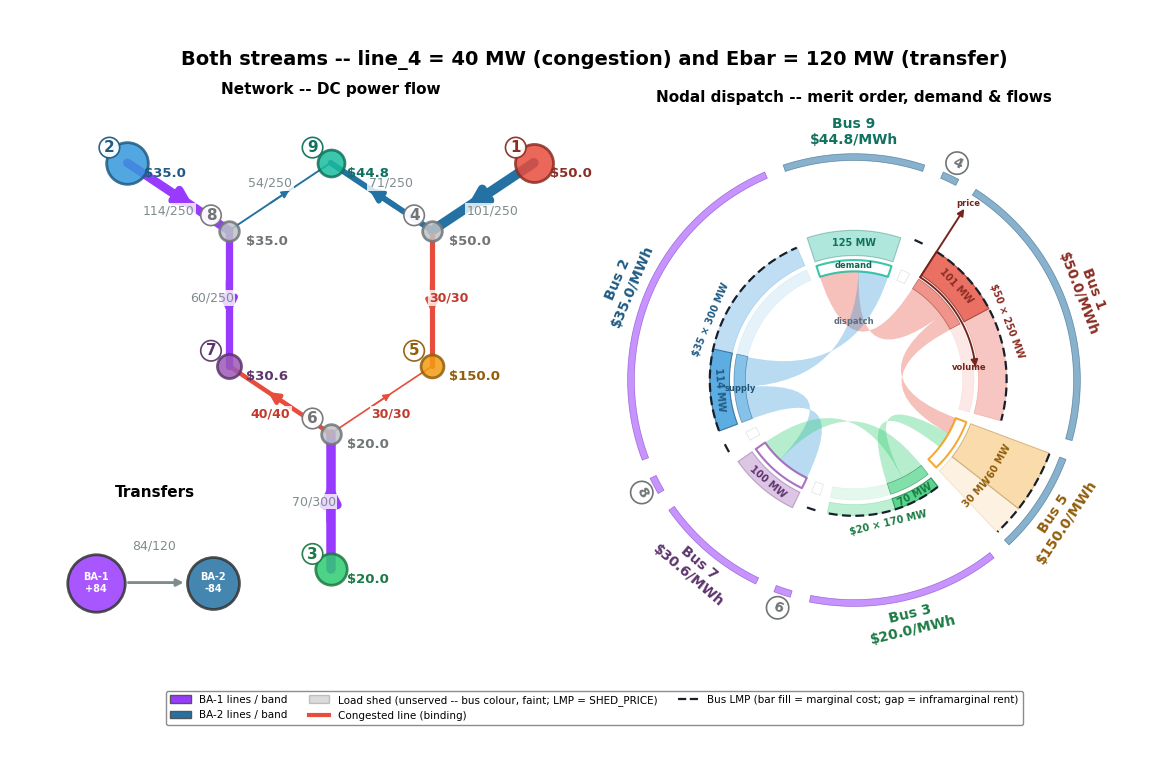

binding lines:

{'line_1': -94.4, 'line_2': 140.4, 'line_4': -4.5}

 |  E = 84 MW,  mu_T = 0.00


per-line congestion rent (binding lines):

,frm,to,kind,home,mu,flow,rent
line,,,,,,,
line_1,4,5,internal,BA-2,-94.39,30.0,2831.7
line_2,5,6,tie,BA-1,140.37,-30.0,4211.0
line_4,6,7,internal,BA-1,-4.46,40.0,178.5


...

BA-1               BA-2              TOTAL
                                           Consumer Generator Consumer Generator         
Autarky: payment / revenue                  -3712.6    2908.5 -10550.9    7082.1  -4272.8
Autarky: production cost                              -2908.5            -7082.1  -9990.6
Autarky: own congestion rent (CRR)            804.1             3468.7             4272.8
Autarky: position                           -2908.5       0.0  -7082.1       0.0  -9990.6
Constrained: payment / revenue              -3061.0    5385.6 -14602.1    5056.3  -7221.2
Constrained: production cost                          -5385.6            -5056.3 -10441.9
Congestion rent collected (assigned lines)   4389.5             2831.7             7221.2
Congestion rent allocated (CRR)              4389.5             2831.7             7221.2
Transfer rent collected (border)                                                      0.0
Transfer rent allocated (CRR)                   0.0                0.0                0.0
Final position                               1328.5       0.0 -11770.4       0.0 -10441.9
Delta vs autarky                             4237.0       0.0  -4688.3       0.0   -451.3
Pareto (Delta >= 0)                             yes       yes       no       yes


Method 2 -- rebate the cross-border separation tau to the net-payer BA;  transfer rent by T1 -- fixed shares (TRANSFER_SPLIT):

BA-1               BA-2              TOTAL
                                           Consumer Generator Consumer Generator         
Autarky: payment / revenue                  -3712.6    2908.5 -10550.9    7082.1  -4272.8
Autarky: production cost                              -2908.5            -7082.1  -9990.6
Autarky: own congestion rent (CRR)            804.1             3468.7             4272.8
Autarky: position                           -2908.5       0.0  -7082.1       0.0  -9990.6
Constrained: payment / revenue              -3061.0    5385.6 -14602.1    5056.3  -7221.2
Constrained: production cost                          -5385.6            -5056.3 -10441.9
Congestion rent collected (assigned lines)   4389.5             2831.7             7221.2
Congestion rent allocated (CRR)               -39.4             7260.6             7221.2
Transfer rent collected (border)                                                      0.0
Transfer rent allocated (CRR)                   0.0                0.0                0.0
Final position                              -3100.3       0.0  -7341.5       0.0 -10441.9
Delta vs autarky                             -191.8       0.0   -259.4       0.0   -451.3
Pareto (Delta >= 0)                              no       yes       no       yes


Method 2 -- rebate the cross-border separation tau to the net-payer BA;  transfer rent by T2 -- all to the net-payer BA:

BA-1               BA-2              TOTAL
                                           Consumer Generator Consumer Generator         
Autarky: payment / revenue                  -3712.6    2908.5 -10550.9    7082.1  -4272.8
Autarky: production cost                              -2908.5            -7082.1  -9990.6
Autarky: own congestion rent (CRR)            804.1             3468.7             4272.8
Autarky: position                           -2908.5       0.0  -7082.1       0.0  -9990.6
Constrained: payment / revenue              -3061.0    5385.6 -14602.1    5056.3  -7221.2
Constrained: production cost                          -5385.6            -5056.3 -10441.9
Congestion rent collected (assigned lines)   4389.5             2831.7             7221.2
Congestion rent allocated (CRR)               -39.4             7260.6             7221.2
Transfer rent collected (border)                                                      0.0
Transfer rent allocated (CRR)                   0.0                0.0                0.0
Final position                              -3100.3       0.0  -7341.5       0.0 -10441.9
Delta vs autarky                             -191.8       0.0   -259.4       0.0   -451.3
Pareto (Delta >= 0)                              no       yes       no       yes

In [22]:
# Both revenue streams at once: the Section-2 internal limit AND the binding border.
# line_4 (6-7, internal to BA-1) at 40 MW collects congestion rent on BA-1's
# wires; the schedule at Ebar = XFER_BIND collects transfer rent on the border.
netC, ptC, engC, resC = solve_with_transfer(dict(LINE_RATINGS), XFER_BIND)
fig = transfer_figure(netC, ptC, engC, resC, XFER_BIND,
                      suptitle=f'Both streams -- line_4 = {LINE_RATINGS["line_4"]:.0f} MW '
                               f'(congestion) and Ebar = {XFER_BIND:.0f} MW (transfer)')
plt.show()

RTC = transfer_rent(resC)
allocC, summC, lrC, sepC = allocate_congestion_rent(resC, ptC, LOADS_ALL)
print('binding lines:', {l: round(mu, 1) for l, mu in resC.line_dual.items()
                         if abs(mu) > 1e-3},
      f' |  E = {resC.interchange_mw:.0f} MW,  mu_T = {resC.interchange_dual:.2f}')
print('\nper-line congestion rent (binding lines):')
display(lrC[lrC.rent > 1e-3].round({'rent': 1}))

print('cross-border price-gap decomposition (eq. 9) -- raw gap = line congestion + transfer;')
print('Method 2 moves only the congestion part (tau), the transfer part is settled as R_T:')
display(sepC[['flow', 'dlam', 'dlam_cong', 'dlam_xfer', 'sep_rent']].round({'sep_rent': 1}))

sC = ba_settlement(resC, LOADS_ALL)
wedgeC = sum(sC[ba]['net_into_pool'] for ba in BA_DEFS)
print(f'conservation:  load pays - gen paid = {wedgeC:,.1f}   vs   R + R_T = '
      f'{summC["R"]:,.1f} + {RTC:,.1f} = {summC["R"] + RTC:,.1f}')

# Autarky counterfactual on the SAME ratings (line_4 = 40, the Section-3 one).
_, indepC = independent_clear(dict(LINE_RATINGS), shed_price=SHED_PRICE)
_M_NAMES = {1: 'Method 1 -- congestion rent stays with the managing BA',
            2: 'Method 2 -- rebate the cross-border separation tau to the net-payer BA'}
# One ledger per configured (congestion, transfer) methodology pair -- trim
# either list in the EDIT cell to show fewer tables. Only the two allocated
# rows move between tables; collected rows and every total are invariant.
for _m in CONGESTION_METHODS:
    for _t in TRANSFER_METHODS:
        print('\n' + _M_NAMES.get(_m, f'Method {_m}')
              + f';  transfer rent by {T_NAMES.get(_t, _t)}:')
        display(transfer_ledger(resC, ptC, LOADS_ALL, _m, _t, indepC))


**Read it.** With only the border constrained (middle example) prices are flat
within each BA — two energy prices linked by a constrained schedule, EDAM's
per-BAA structure in miniature — and the whole settlement wedge is transfer
rent, $R_T=|\mu_T E|$, split by the configured shares. With `line_4` back at 40 MW (last example)
the **two revenue streams coexist**: BA-1's internal wire collects congestion
rent $R$ exactly as in Section 3, the border schedule collects $R_T$ on top, and
the wedge is their sum — the conservation line checks it to the cent. Note the
interplay: with the internal limit in place $|\mu_T|$ is *larger* than in the
pure-border case, because the redispatch the schedule forces interacts with the
congested wire.

The middle example is also where eq. (9)'s constraint-based $\tau$ earns its
keep. The raw price gap across each tie is $|\mu_T|$ — but no **line** is binding,
so the congestion component of that gap is zero, $\tau=0$, and Methods 1 and 2
genuinely coincide: the border's separation is settled once, as $R_T$, not a second
time through a rebate. In the combined example the decomposition table makes the
same point line by line: each tie's raw gap splits into a line-congestion part
(`dlam_cong`, the only piece $\tau$ prices and Method 2 moves) and a transfer part
(`dlam_xfer` $=\pm\mu_T$, settled as $R_T$ by the configured transfer rule) — every dollar of separation
settled exactly once, by the constraint that created it.

The autarky block prices the distributional story. Constrained trade still
beats autarky in total — the TOTAL of the *Delta vs autarky* row is exactly the
production-cost saving — but the gains need not reach everyone. In the middle
example BA-1's **consumers** end up *worse* than autarky (the export pulls
their cheap unit away and their price rises from \$20 toward the importer's
\$50) even as BA-1's **generators** gain several times that: the border fails the
Pareto check on one column. With `line_4` back at 40 MW the autarky baseline is
itself expensive enough that every column clears the check under the default
50/50 — but the methodology grid has corners: stack **both** rebates on the
net-payer (Method 2 x T2) and the exporter's consumers drop below autarky
again, while Method 1 x T2 leaves them exactly at their autarky position. How much of each rent is
rebated to whom — `CONGESTION_METHODS`, `TRANSFER_METHODS` — is what decides
whether integrating across the border is merely efficient or actually Pareto-improving:
switching the transfer rule from T1 to T2 moves the whole rebate to the
importer and *deepens* the exporter-consumer loss — the methodology choice is
pure distribution, the production-cost saving never moves.



### Where this goes next

The scaffold above is the **methodology**: a unified nodal clearing, a
congestion-revenue ledger split by the configurable line assignment, and the two
allocation rules (home-keeps-it vs rebate-cross-border-separation) compared on an
internal-constraint case, alongside the unified-vs-separated contrast.

Planned refinements (to work through next):

1. **Multi-part supply curves per BA** — replace the discrete
   three-unit fleet so generator profit changes.
2. **Sweep the tie / internal limit** and trace how $\tau$ and each BA's net
   revenue/expense move.
3. **Refine the allocation rules now exposed as knobs** — Method 2's recipient
   rule (e.g. split $\tau$ between importer load and exporter generation rather
   than a single directed transfer) and the transfer methodologies in
   `allocate_transfer_rent` (`TRANSFER_METHODS`: fixed shares vs
   all-to-net-payer today — richer cost-causation rules are a natural
   exercise). The old $\tau$ double-count is already
   resolved: eq. (9) prices $\tau$ from the line constraints only.